In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df = pd.read_csv('Earthquake1995.csv')
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [3]:
df.isnull().sum() #checking for data cleaning

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        551
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       6
continent    716
country      349
dtype: int64

In [4]:
df.drop(columns=['net'], inplace=True, axis=1)  #Dropping the unused column
df.head() #making sure

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
#getting the rows that have a null in location
df[df['location'].isna()]

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
30,M 6.8 -,6.8,20-01-2023 22:09,4,3,green,0,718,60,5.129,61.0,mww,610.671,-26.7209,-63.0394,NaN,South America,Argentina
37,M 7.0 -,7.0,12/11/2022 7:09,3,3,green,1,755,147,3.125,18.0,mww,579.000,-20.0508,-178.3460,NaN,Oceania,Fiji
39,M 6.6 -,6.6,9/11/2022 10:14,0,2,green,1,670,131,4.998,27.0,mww,624.464,-25.5948,178.2780,NaN,NaN,NaN
54,M 6.9 -,6.9,19-05-2022 10:13,2,5,green,1,733,127,0.371,45.0,mww,10.000,-54.1325,159.0270,NaN,NaN,NaN
103,M 6.9 -,6.9,1/5/2021 1:27,7,6,green,1,919,0,2.619,35.0,mww,43.000,38.2296,141.6650,NaN,Asia,Japan
281,M 6.9 -,6.9,28-05-2016 05:38,3,3,green,1,733,0,5.485,19.0,mww,405.690,-21.9724,-178.2040,NaN,NaN,NaN


In [7]:
!pip install geopy

In [8]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="earthquakeproj")

def get_location(lat, lon):
    location = geolocator.reverse(f"{lat}, {lon}", zoom=5)
    if location is None:
        return "Unknown"
    return location.address

# Apply only to null rows
locationsNull = df['location'].isna()
df.loc[locationsNull, 'location'] = df.loc[locationsNull].apply(
    lambda row: get_location(row['latitude'], row['longitude']), axis=1
)

In [9]:
#Make sure it worked
df[df['location'].isna()]

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country


In [10]:
#Filling in the nulls of country
df.loc[39, 'location'] = 'Kermadec Islands'
df['country'] = df['location'].str.extract(r',\s*([^,]+)$')[0].fillna(df['location'])
df.head(40)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,El Salvador
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,Alaska
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,Alaska Peninsula
5,"M 6.6 - 277 km NNE of Codrington, Antigua and ...",6.6,10/7/2023 20:28,5,4,green,1,802,95,2.454000,37.0,mww,10.000,20.0196,-61.0955,"Codrington, Antigua and Barbuda",NaN,Antigua and Barbuda
6,M 6.9 - Tonga,6.9,2/7/2023 10:27,4,4,green,1,741,136,1.179000,23.0,mww,229.000,-17.8530,-174.9370,Tonga,NaN,Tonga
7,M 7.2 - south of the Fiji Islands,7.2,15-06-2023 18:06,8,6,green,1,804,85,2.590000,24.0,mww,167.404,-22.9824,-177.2080,the Fiji Islands,NaN,the Fiji Islands
8,M 6.6 - Panama-Colombia border region,6.6,25-05-2023 03:05,6,6,green,1,733,50,2.163000,129.0,mww,10.000,8.8894,-77.1231,Panama-Colombia border region,NaN,Panama-Colombia border region
9,M 7.1 - southeast of the Loyalty Islands,7.1,20-05-2023 01:51,3,4,green,1,777,98,2.812000,56.0,mww,35.981,-23.0622,170.4560,the Loyalty Islands,NaN,the Loyalty Islands


In [11]:
#Will use unique to get an array of all unique countries to find which ones are the ones that arent real countries to fix 
df['country'].unique()

array(['Vanuatu', 'El Salvador', 'Argentina', 'Alaska',
       'Alaska Peninsula', 'Antigua and Barbuda', 'Tonga',
       'the Fiji Islands', 'Panama-Colombia border region',
       'the Loyalty Islands', 'Indonesia', 'New Zealand', 'Russia',
       'Papua New Guinea', 'Afghanistan', 'Ecuador',
       'Kermadec Islands region', 'Tajikistan', 'Turkey',
       'Central Turkey', 'Solomon Islands', 'Viti', 'Kermadec Islands',
       'Panama', 'Mexico', 'Taiwan', 'China', 'the Kermadec Islands',
       'Philippines', 'Brazil', 'Peru', 'Unknown', 'Nicaragua',
       'New Caledonia', 'Japan', 'Cyprus', 'Timor Leste', 'Flores Sea',
       'Vanuatu region', 'South Sandwich Islands region', 'Haiti',
       'Wallis and Futuna', 'Mauritius - Reunion region', '日本',
       'South Shetland Islands', 'Mongolia', 'Chile', 'Greece',
       'central Mid-Atlantic Ridge', 'NV Earthquake', 'Banda Sea',
       'Idaho', 'Jamaica', 'Fiji', 'South Sandwich Islands', 'Australia',
       'CA', 'Prince Edward Isla

In [12]:
#There are countries listed from the above fix that are not acutally real countries
fix = {
"Alaska": "United States of America",
"Alaska Peninsula": "United States of America",
"California": "United States of America",
"CA": "United States of America",
"CA Earthquake": "United States of America",
"NV Earthquake": "United States of America",
"Idaho": "United States of America",
"Hawaii": "United States of America",
"Washington": "United States of America",
"Russia": "Russia",
"Russia region": "Russia",
"Kuril Islands": "Russia",
"the Kuril Islands": "Russia",
"Okhotsk": "Russia",
"Japan region": "Japan",
"Central Turkey": "Turkey",
"Flores Sea": "Indonesia",
"Banda Sea": "Indonesia",
"Molucca Sea": "Indonesia",
"Kermadec Islands region": "New Zealand",
"the Kermadec Islands": "New Zealand",
"Macquarie Island": "New Zealand",
"New Zealand region": "New Zealand",
"the Fiji Islands": "Fiji",
"Fiji region": "Fiji",
"the Loyalty Islands": "New Caledonia",
"Loyalty Islands": "New Caledonia",
"Panama-Colombia border region": "Colombia",
"South Sandwich Islands": "United Kingdom",
"South Sandwich Islands region": "United Kingdom",
"South Shetland Islands": "Antarctica",
"Ant": "Antarctica",
"central Mid-Atlantic Ridge": "Atlantic Ocean",
"northern Mid-Atlantic Ridge": "Atlantic Ocean",
"South Indian Ocean": "Indian Ocean",
"Scotia Sea": "Atlantic Ocean",
"Micronesia region": "Micronesia",
"Philippine Islands region": "Philippines",
"Mauritius - Reunion region": "Mauritius",
"Bouvet Island region": "Norway",
"Prince Edward Islands region": "South Africa",
"Afghanistan-Tajikistan-Pakistan region": "Afghanistan",
"2004 Sumatra - Andaman Islands Earthquake": "Indonesia",
"Vanuatu region": "Vanauatu",
"United Kingdom of Great Britain and Northern Ireland (the)": "United Kingdom",
"Svalbard and Jan Mayen": "Norway",
"India region": "India",
"off the west coast of northern Sumatra": "Indonesia",
"MX": "Mexico",
"Democratic Republic": "DRC",
"western Xizang": "People's Republic of China",
"Turkmenistan-Iran border region": "Turkmenistan",
"Kermadec Islands": "New Zealand",
"日本": "People's Republic of China"
}

df['country'] = df['country'].replace(fix)

df['country'].unique()

array(['Vanuatu', 'El Salvador', 'Argentina', 'United States of America',
       'Antigua and Barbuda', 'Tonga', 'Fiji', 'Colombia',
       'New Caledonia', 'Indonesia', 'New Zealand', 'Russia',
       'Papua New Guinea', 'Afghanistan', 'Ecuador', 'Tajikistan',
       'Turkey', 'Solomon Islands', 'Viti', 'Panama', 'Mexico', 'Taiwan',
       'China', 'Philippines', 'Brazil', 'Peru', 'Unknown', 'Nicaragua',
       'Japan', 'Cyprus', 'Timor Leste', 'Vanauatu', 'United Kingdom',
       'Haiti', 'Wallis and Futuna', 'Mauritius',
       "People's Republic of China", 'Antarctica', 'Mongolia', 'Chile',
       'Greece', 'Atlantic Ocean', 'Jamaica', 'Australia', 'South Africa',
       'Norway', 'Canada', 'Venezuela', 'Bolivia', 'Honduras',
       'Costa Rica', 'Iraq', 'Guatemala', 'Botswana', 'Italy', 'Myanmar',
       'Northern Mariana Islands', 'India', 'Barbados', 'Nepal', 'Guam',
       'Micronesia', 'Pakistan', 'Iran', 'Samoa', 'Kyrgyzstan',
       'Martinique', 'S', 'Zimbabwe', 'DRC', 'Cay

In [13]:
!pip install pycountry pycountry-convert

In [14]:

import pycountry
import pycountry_convert as pc

def country_to_continent(country):
    try:
        country_obj = pycountry.countries.lookup(country)
        code = country_obj.alpha_2
        cont_code = pc.country_alpha2_to_continent_code(code)

        continents = {
            'AF': 'Africa',
            'AS': 'Asia',
            'EU': 'Europe',
            'NA': 'North America',
            'SA': 'South America',
            'OC': 'Oceania',
            'AN': 'Antarctica'
        }

        return continents[cont_code]

    except:
        return None

df['continent'] = df['country'].apply(country_to_continent)
df.head(20)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Oceania,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",North America,El Salvador
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",North America,United States of America
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,North America,United States of America
5,"M 6.6 - 277 km NNE of Codrington, Antigua and ...",6.6,10/7/2023 20:28,5,4,green,1,802,95,2.454000,37.0,mww,10.000,20.0196,-61.0955,"Codrington, Antigua and Barbuda",North America,Antigua and Barbuda
6,M 6.9 - Tonga,6.9,2/7/2023 10:27,4,4,green,1,741,136,1.179000,23.0,mww,229.000,-17.8530,-174.9370,Tonga,Oceania,Tonga
7,M 7.2 - south of the Fiji Islands,7.2,15-06-2023 18:06,8,6,green,1,804,85,2.590000,24.0,mww,167.404,-22.9824,-177.2080,the Fiji Islands,Oceania,Fiji
8,M 6.6 - Panama-Colombia border region,6.6,25-05-2023 03:05,6,6,green,1,733,50,2.163000,129.0,mww,10.000,8.8894,-77.1231,Panama-Colombia border region,South America,Colombia
9,M 7.1 - southeast of the Loyalty Islands,7.1,20-05-2023 01:51,3,4,green,1,777,98,2.812000,56.0,mww,35.981,-23.0622,170.4560,the Loyalty Islands,Oceania,New Caledonia


In [15]:
df['alert'] = df['alert'].fillna('No Warning Issued')

In [16]:
df.dtypes

title         object
magnitude    float64
date_time     object
cdi            int64
mmi            int64
alert         object
tsunami        int64
sig            int64
nst            int64
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
location      object
continent     object
country       object
dtype: object

In [17]:
#Converting date column to datetime
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed', dayfirst=True)

In [18]:
df.dtypes
#Now the date and time has been changed from object(Strigng) to date and time

title                object
magnitude           float64
date_time    datetime64[ns]
cdi                   int64
mmi                   int64
alert                object
tsunami               int64
sig                   int64
nst                   int64
dmin                float64
gap                 float64
magType              object
depth               float64
latitude            float64
longitude           float64
location             object
continent            object
country              object
dtype: object

In [19]:
#Making Label Encoding For the Alert Level:
from sklearn import preprocessing 

label_encoder = preprocessing.LabelEncoder() 
df['AlertEncoded']= label_encoder.fit_transform(df['alert']) 
df.tail()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,AlertEncoded
995,"M 7.1 - 85 km S of Tungor, Russia",7.1,1995-05-27 13:03:00,0,9,No Warning Issued,0,776,0,0.0,0.0,mwb,11.0,52.629,142.827,"Tungor, Russia",None,Russia,0
996,"M 7.7 - 249 km E of Vao, New Caledonia",7.7,1995-05-16 20:12:00,0,4,No Warning Issued,0,912,0,0.0,0.0,mw,20.2,-23.008,169.900,"Vao, New Caledonia",Oceania,New Caledonia,0
997,"M 6.9 - 27 km NNW of Maubara, Timor Leste",6.9,1995-05-14 11:33:00,0,6,No Warning Issued,0,732,0,0.0,0.0,mw,11.2,-8.378,125.127,"Maubara, Timor Leste",None,Timor Leste,0
998,"M 6.6 - 10 km W of Aianí, Greece",6.6,1995-05-13 08:47:00,0,9,No Warning Issued,0,670,0,0.0,0.0,mw,14.0,40.149,21.695,"Aianí, Greece",Europe,Greece,0
999,"M 7.1 - 14 km NE of Cabatuan, Philippines",7.1,1995-05-05 03:53:00,0,7,No Warning Issued,0,776,0,0.0,0.0,mw,16.0,12.626,125.297,"Cabatuan, Philippines",Asia,Philippines,0


In [20]:
#Creating a new Column called Year which we might use for visulization later
df['year'] = df['date_time'].dt.year


# Aggregations

In [21]:
#Getting mean of earthquakes per continent
df.groupby('continent')['magnitude'].mean()

continent
Africa           6.771429
Asia             6.944864
Europe           6.783871
North America    6.922143
Oceania          6.929139
South America    6.964602
Name: magnitude, dtype: float64

In [22]:
#Mean of tsunamis per region, to see which region is closest to 1 (Which would mean it has the most tsunamis)
df.groupby('continent')['tsunami'].mean()

continent
Africa           0.000000
Asia             0.141994
Europe           0.419355
North America    0.464286
Oceania          0.460265
South America    0.309735
Name: tsunami, dtype: float64

In [23]:
#To see the mean of magnitudes that cause tsunamis and also seeing if alerts correspond correctly to the magnitude of the earthquake
df.where(df.tsunami == 1).groupby('alert')[['magnitude']].mean()

,magnitude
alert,
No Warning Issued,6.716667
green,6.898077
orange,7.300000
red,7.340000
yellow,7.076190


In [24]:
#Seeing highest and lowest magnitude of earthquakes per continent
df.groupby('continent')['magnitude'].agg(['max', 'min'])

,max,min
continent,,
Africa,7.2,6.5
Asia,9.1,6.5
Europe,8.1,6.5
North America,8.2,6.5
Oceania,8.2,6.5
South America,8.8,6.5


In [25]:
#seeing the percentage of earthquakes that have caused a tsunami
df['tsunami'].value_counts()

tsunami
0    675
1    325
Name: count, dtype: int64

# Binning

In [26]:
#Giving Each Earthquake a score by bins
bins = (6.4,7.5,8.5,9.5)
labels=("Strong","Very Strong","Destructive")

df['Earthquake Score'] = pd.cut(df['magnitude'], bins = bins, labels=labels)

df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,magType,depth,latitude,longitude,location,continent,country,AlertEncoded,year,Earthquake Score
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,114,7.177000,...,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,1,2023,Strong
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,92,0.679000,...,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",North America,El Salvador,4,2023,Strong
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,70,1.634000,...,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,1,2023,Strong
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,173,0.907000,...,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",North America,United States of America,1,2023,Strong
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,No Warning Issued,1,820,79,0.879451,...,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,North America,United States of America,0,2023,Strong


In [27]:
#Earthquake types ordered by frequency
df['Earthquake Score'].value_counts()

Earthquake Score
Strong         884
Very Strong    111
Destructive      5
Name: count, dtype: int64

In [28]:
#seeing minimum and maximum depth of earthquakes per
df.groupby('continent')['depth'].agg(['max', 'min'])

,max,min
continent,,
Africa,34.00,10.00
Asia,664.00,6.80
Europe,133.00,6.00
North America,176.40,2.70
Oceania,670.81,6.43
South America,630.00,5.00


# Binning for depth

# WILL DO LATER


In [29]:
#Finding countries by counts of their earthquakes, top 10 dangerous countries to be in for earthquakes
df.groupby('country')['magnitude'].count().sort_values(ascending=False).head(10)

country
Indonesia                   140
Papua New Guinea             98
Japan                        74
Vanuatu                      54
Chile                        54
United States of America     49
Solomon Islands              43
Mexico                       39
Russia                       38
Philippines                  36
Name: magnitude, dtype: int64

In [30]:
df.groupby('year')['magnitude'].max()

#Question for later, is it random, increasing or decreasing?

year
1995    8.00
1996    8.09
1997    7.80
1998    7.70
1999    7.70
2000    8.00
2001    8.40
2002    7.90
2003    8.16
2004    9.10
2005    8.60
2006    8.30
2007    8.40
2008    7.90
2009    8.10
2010    8.80
2011    9.10
2012    8.60
2013    8.30
2014    8.20
2015    8.30
2016    7.90
2017    8.20
2018    8.20
2019    8.00
2020    7.80
2021    8.20
2022    7.60
2023    7.80
Name: magnitude, dtype: float64

In [31]:
#seeing which is the most common magtype
df['magType'].value_counts()

magType
mww    502
mwc    332
mwb    100
mw      51
Mi       5
mb       4
ms       3
md       2
ml       1
Name: count, dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             1000 non-null   object        
 1   magnitude         1000 non-null   float64       
 2   date_time         1000 non-null   datetime64[ns]
 3   cdi               1000 non-null   int64         
 4   mmi               1000 non-null   int64         
 5   alert             1000 non-null   object        
 6   tsunami           1000 non-null   int64         
 7   sig               1000 non-null   int64         
 8   nst               1000 non-null   int64         
 9   dmin              1000 non-null   float64       
 10  gap               1000 non-null   float64       
 11  magType           1000 non-null   object        
 12  depth             1000 non-null   float64       
 13  latitude          1000 non-null   float64       
 14  longitude         1000 no

In [33]:
df.describe()

,magnitude,date_time,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude,AlertEncoded,year
count,1000.000000,1000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,6.940150,2010-06-19 03:02:36.720000,3.605000,6.02700,0.325000,847.915000,193.918000,1.125174,20.926290,74.612541,4.315554,51.486576,0.676000,2009.95900
min,6.500000,1995-05-05 03:53:00,0.000000,1.00000,0.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,0.000000,1995.00000
25%,6.600000,2003-08-17 04:18:15,0.000000,5.00000,0.000000,691.000000,0.000000,0.000000,0.000000,16.000000,-13.518500,-71.694450,0.000000,2003.00000
50%,6.800000,2011-06-29 20:26:30,4.000000,6.00000,0.000000,744.000000,0.000000,0.000000,18.000000,29.000000,-2.443500,107.791000,0.000000,2011.00000
75%,7.100000,2017-02-22 08:58:45,7.000000,7.00000,1.000000,874.250000,403.000000,1.549250,27.000000,55.000000,25.167250,148.364750,1.000000,2017.00000
max,9.100000,2023-08-16 12:47:00,9.000000,10.00000,1.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,4.000000,2023.00000
std,0.438148,NaN,3.328972,1.43399,0.468609,301.802632,239.045858,2.073164,24.415895,130.812590,26.633320,117.478302,1.026683,8.24617


In [34]:
df.drop_duplicates()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,magType,depth,latitude,longitude,location,continent,country,AlertEncoded,year,Earthquake Score
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,114,7.177000,...,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,1,2023,Strong
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,92,0.679000,...,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",North America,El Salvador,4,2023,Strong
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,70,1.634000,...,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,1,2023,Strong
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,173,0.907000,...,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",North America,United States of America,1,2023,Strong
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,No Warning Issued,1,820,79,0.879451,...,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,North America,United States of America,0,2023,Strong
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"M 7.1 - 85 km S of Tungor, Russia",7.1,1995-05-27 13:03:00,0,9,No Warning Issued,0,776,0,0.000000,...,mwb,11.000,52.6290,142.8270,"Tungor, Russia",None,Russia,0,1995,Strong
996,"M 7.7 - 249 km E of Vao, New Caledonia",7.7,1995-05-16 20:12:00,0,4,No Warning Issued,0,912,0,0.000000,...,mw,20.200,-23.0080,169.9000,"Vao, New Caledonia",Oceania,New Caledonia,0,1995,Very Strong
997,"M 6.9 - 27 km NNW of Maubara, Timor Leste",6.9,1995-05-14 11:33:00,0,6,No Warning Issued,0,732,0,0.000000,...,mw,11.200,-8.3780,125.1270,"Maubara, Timor Leste",None,Timor Leste,0,1995,Strong
998,"M 6.6 - 10 km W of Aianí, Greece",6.6,1995-05-13 08:47:00,0,9,No Warning Issued,0,670,0,0.000000,...,mw,14.000,40.1490,21.6950,"Aianí, Greece",Europe,Greece,0,1995,Strong


# Ahmed abousheisha's Visulization

# Q1: What degree of correlation (depth/magnitude) do tangible measurements yield versus perceived severity via human perception (CDI, MMI, SIG) by region?

In [35]:
corr_matrix = df[['depth', 'magnitude', 'cdi', 'mmi', 'sig']].corr().round(2)
print("Overall Correlations:")
print(corr_matrix)

print("\nBy Continent:")
for cont in df['continent'].dropna().unique():
    sub = df[df['continent'] == cont]
    if len(sub) > 30:
        print(f"\n{cont}:")
        print(sub[['depth', 'magnitude', 'cdi', 'mmi', 'sig']].corr().round(2))

Overall Correlations:
           depth  magnitude   cdi   mmi   sig
depth       1.00       0.02 -0.05 -0.52 -0.08
magnitude   0.02       1.00  0.16  0.28  0.51
cdi        -0.05       0.16  1.00  0.20  0.48
mmi        -0.52       0.28  0.20  1.00  0.40
sig        -0.08       0.51  0.48  0.40  1.00

By Continent:

Oceania:
           depth  magnitude   cdi   mmi   sig
depth       1.00      -0.02 -0.07 -0.56 -0.05
magnitude  -0.02       1.00  0.27  0.37  0.90
cdi        -0.07       0.27  1.00  0.21  0.36
mmi        -0.56       0.37  0.21  1.00  0.41
sig        -0.05       0.90  0.36  0.41  1.00

North America:
           depth  magnitude   cdi   mmi   sig
depth       1.00       0.01 -0.03 -0.02 -0.09
magnitude   0.01       1.00  0.23  0.38  0.54
cdi        -0.03       0.23  1.00  0.27  0.61
mmi        -0.02       0.38  0.27  1.00  0.53
sig        -0.09       0.54  0.61  0.53  1.00

South America:
           depth  magnitude   cdi   mmi   sig
depth       1.00      -0.01 -0.08 -0.78 -0.10
m

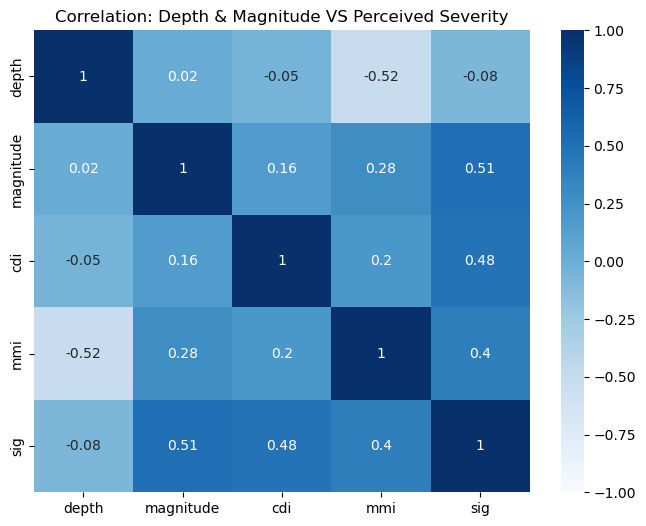

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='Blues',vmin=-1,vmax=1)
plt.title("Correlation: Depth & Magnitude VS Perceived Severity")
plt.show()

# Q2: Is there a statistically significant relationship between earthquake magnitude and reported damage severity (SIG) across regions?

In [37]:
print("Overall Correlation (Magnitude vs SIG):")

corr = df[['magnitude', 'sig']].corr().iloc[0,1]
print(f"Correlation = {corr:.3f}")
print("\nBy Continent:")

for cont in df['continent'].dropna().unique():
    sub = df[df['continent'] == cont]
    
    if len(sub) > 30:
        corr = sub[['magnitude','sig']].corr().iloc[0,1]
        print(f"{cont:20} Correlation = {corr:.3f}")

Overall Correlation (Magnitude vs SIG):
Correlation = 0.512

By Continent:
Oceania              Correlation = 0.898
North America        Correlation = 0.541
South America        Correlation = 0.719
Asia                 Correlation = 0.527
Europe               Correlation = 0.107


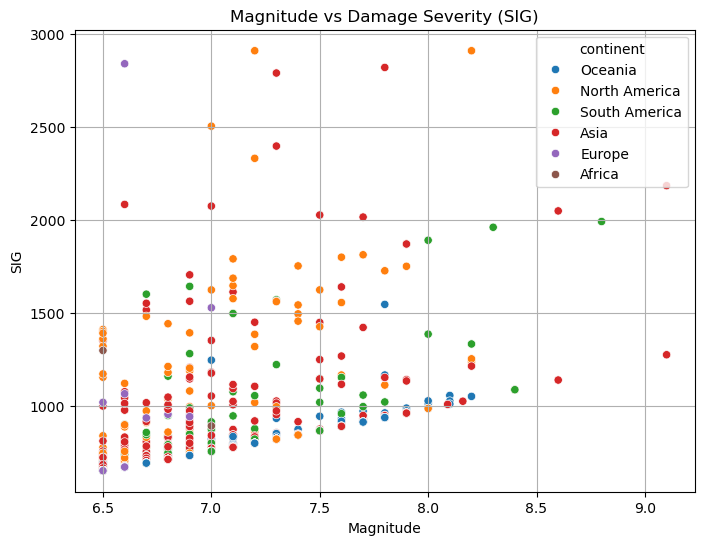

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='magnitude',y='sig',hue='continent',alpha=1)
plt.title("Magnitude vs Damage Severity (SIG)")
plt.xlabel("Magnitude")
plt.ylabel("SIG")
plt.grid(True)
plt.show()

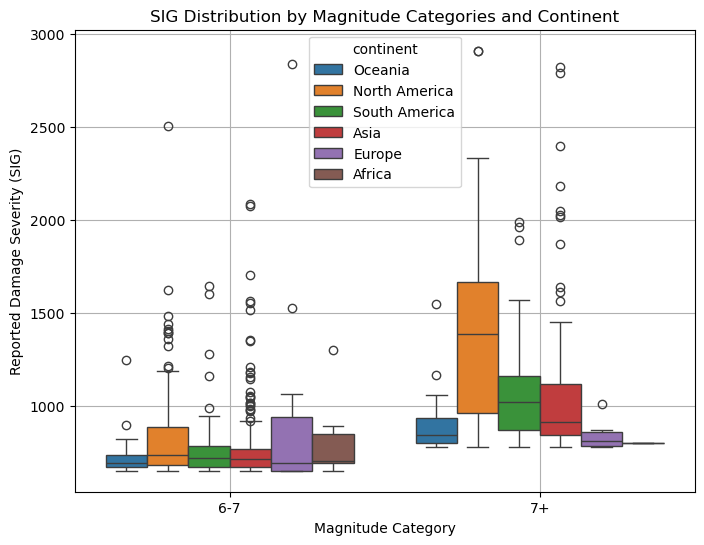

In [39]:
plt.figure(figsize=(8,6))

df['mag_category'] = pd.cut(df['magnitude'], bins=[6, 7, 10], labels=['6-7','7+'])

sns.boxplot(data=df, x='mag_category', y='sig', hue='continent')

plt.title("SIG Distribution by Magnitude Categories and Continent")
plt.xlabel("Magnitude Category")
plt.ylabel("Reported Damage Severity (SIG)")
plt.grid(True)
plt.show()

# Q3: Are there noticeably different (more variable) uncertainty indicators (greater GAP and fewer NST) for deeper earthquakes compared to shallower earthquakes?

In [40]:
df['depth_category'] = pd.cut(df['depth'], bins=[0, 70, 300, 700],labels=['Shallow', 'Intermediate', 'Deep'])
uncertainty = df.groupby('depth_category', observed=False)[['gap','nst']].agg(['mean','std'])
print("\nUncertainty by Depth Category:")
print(uncertainty)


Uncertainty by Depth Category:
                      gap                    nst            
                     mean        std        mean         std
depth_category                                              
Shallow         22.231926  26.716572  200.705957  236.364506
Intermediate    14.833987  11.544144  199.078431  262.845575
Deep            19.236207   9.946219   87.965517  181.067785


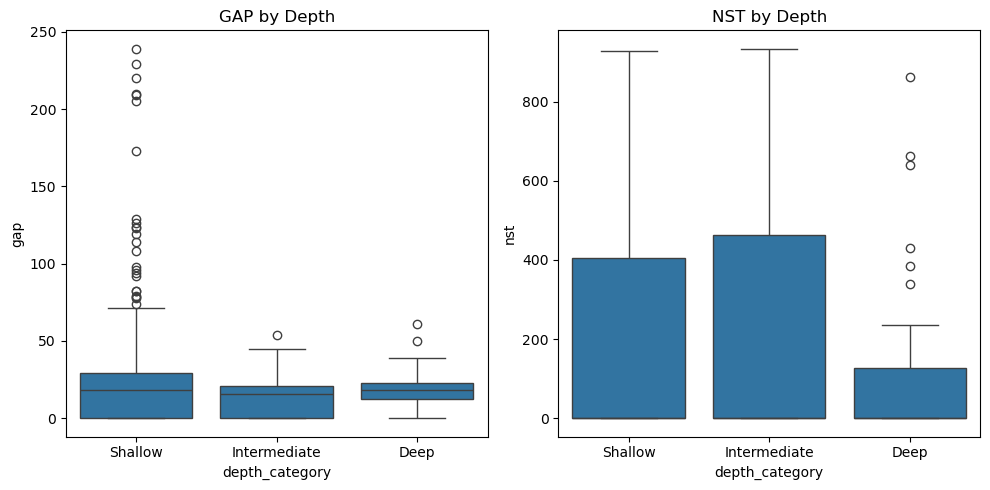

In [41]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, x='depth_category', y='gap')
plt.title("GAP by Depth")

plt.subplot(1,2,2)
sns.boxplot(data=df, x='depth_category', y='nst')
plt.title("NST by Depth")

plt.tight_layout()
plt.show()

# _______________________________________________________________________________________

# Mohamed Hesham's Visulization

# Mohamed's Questions:
### are shallow earthquakes (Ones with a small depth) more likely to cause a tsunami than deeper earthquakes for earthquakes with similar magnitude?

### Does the magnitude and the location of the earthquake have any effect on whether a tsunami happens or not?

### Which Magtype shows values closest to what the humans actually felt and percieved (Which magtype is the most accurate or most humanlike in feeling)?


# Question 1:

In [42]:
#Seeing maximum and minimum depths
depths=df['depth'].agg(['max', 'min'])
depths

max    670.81
min      2.70
Name: depth, dtype: float64

In [43]:
#Seeing maximum and minimum magnitudes to split it into bins
depths=df['magnitude'].agg(['max', 'min'])
depths

#depth bins already calculated above

max    9.1
min    6.5
Name: magnitude, dtype: float64

In [44]:
#Splitting Magnitudes into bins
bins=[6.5,7,7.5,8,8.5,9,9.5]
labels=['6.5-7','7-7.5','7.5-8','8-8.5', '8.5-9','9-9.5']
df['mag_bin'] = pd.cut(df['magnitude'], bins=bins, labels=labels)
#depth bins already calculated above

In [45]:
depth_mag_tsunami = df.groupby(['mag_bin', 'depth_category'])['tsunami'].mean().unstack()
print(depth_mag_tsunami)

depth_category   Shallow  Intermediate      Deep
mag_bin                                         
6.5-7           0.314554      0.337838  0.531250
7-7.5           0.304965      0.358974  0.571429
7.5-8           0.236111      0.538462  0.428571
8-8.5           0.352941           NaN  1.000000
8.5-9           0.000000           NaN       NaN
9-9.5           0.000000           NaN       NaN


C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\3153643041.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  depth_mag_tsunami = df.groupby(['mag_bin', 'depth_category'])['tsunami'].mean().unstack()


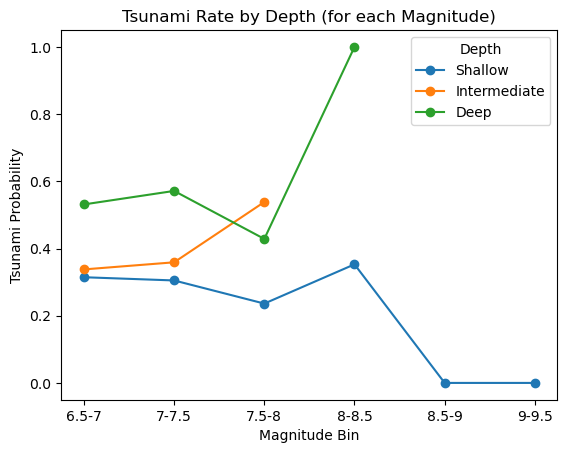

In [46]:
depth_mag_tsunami.plot(kind='line', marker='o')

plt.title("Tsunami Rate by Depth (for each Magnitude)")
plt.xlabel("Magnitude Bin")
plt.ylabel("Tsunami Probability")

plt.legend(title="Depth")
plt.show()

### Answer to question 1: After grouping by magnitude and depth and using the mean tsunami rate of each depth and magnitude together, I have found that shallow earthquakes for the same magnitudes have consistently less rate of tsunamis than deep and intermediate depths. This means that shallow earthquakes are less likely to cause a tsunami than deeper earthquakes for earthquakes of the same magnitude. So the answer to question 1 is: NO!

# Question 2: Does the Magnitude and the location of the earthquake have any affect on whether the tsunami happens or not?

In [47]:
import plotly.express as px

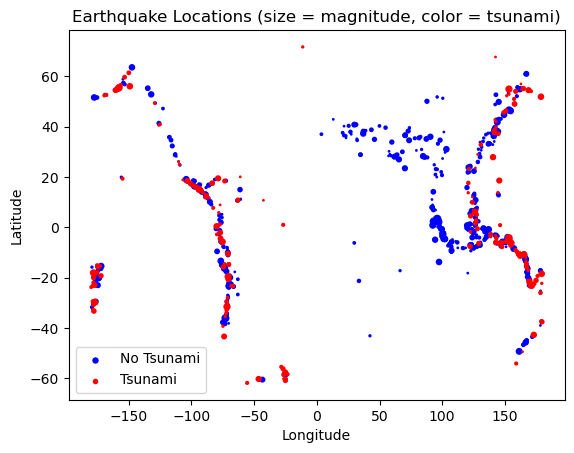

In [48]:
fig, ax = plt.subplots()

no_tsunami = df[df['tsunami'] == 0]
tsunami = df[df['tsunami'] == 1]

ax.scatter(no_tsunami['longitude'], no_tsunami['latitude'], color='blue', label='No Tsunami', sizes=(no_tsunami['magnitude'] - df['magnitude'].min()) * 10)

ax.scatter(tsunami['longitude'], tsunami['latitude'], color='red', label='Tsunami', sizes=(tsunami['magnitude'] - df['magnitude'].min()) * 10)

ax.set_title('Earthquake Locations (size = magnitude, color = tsunami)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.legend()
plt.show()

In [49]:
fig = px.scatter_geo(df, 
                     lat='latitude', 
                     lon='longitude', 
                     color='tsunami',
                     hover_name='country', 
                     size=(df['magnitude'] - df['magnitude'].min()) * 10,
                     title='Earthquakes Around the World')

fig.show()

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\1538642614.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



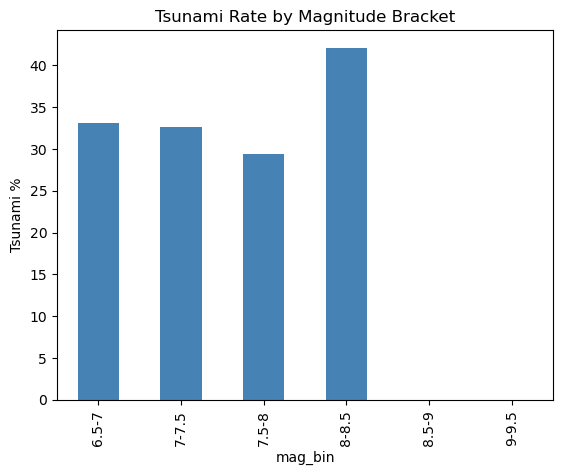

In [50]:
#Magnitudes already split into bins

tsunami_rate = df.groupby('mag_bin')['tsunami'].mean() * 100 #To get how much percent caused tsunamis

tsunami_rate.plot(kind="bar", color="steelblue")
plt.ylabel("Tsunami %")
plt.title("Tsunami Rate by Magnitude Bracket")

plt.show()

In [51]:
# 8.5 to 9.5 does not have a lot of info

### Answering Question 2: It is obvious that the location of the place affects the earthquakes as they are clustered within the same lines. The location alone does affect whether a tsunami happens or not as we can see that tsunamis are clustered within locations that are coastlines mostly. and no, the magnitude does not affect whether a tsunami happens or not because tsunamis happen after all types of magnitude. 
### Final answer to question 2: Yes partly and No partly. The magnitude has no effect but the location does have an effect. Also the bar chart shows that magnitude does not have any relation with whether a tsunami happens or not

# Question 3: Which Magtype shows values closest to what the humans actually felt and percieved (Which magtype is the most accurate or most humanlike in feeling)?

## Magtype is the method used to calculate the magnitude of an earthquake

In [52]:
valid = df["magType"].value_counts()
valid

magType
mww    502
mwc    332
mwb    100
mw      51
Mi       5
mb       4
ms       3
md       2
ml       1
Name: count, dtype: int64

In [53]:
#Will keep only the types with a big sample: (More than 20)
#Copying the dataframe so that we dont ruin the original
df2 = df.copy()
df2.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,longitude,location,continent,country,AlertEncoded,year,Earthquake Score,mag_category,depth_category,mag_bin
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,114,7.177000,...,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,1,2023,Strong,6-7,Intermediate,NaN
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,92,0.679000,...,-88.1265,"Intipucá, El Salvador",North America,El Salvador,4,2023,Strong,6-7,Shallow,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,70,1.634000,...,-70.3731,"Loncopué, Argentina",South America,Argentina,1,2023,Strong,6-7,Intermediate,6.5-7
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,173,0.907000,...,-160.6990,"Sand Point, Alaska",North America,United States of America,1,2023,Strong,7+,Shallow,7-7.5
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,No Warning Issued,1,820,79,0.879451,...,-160.7960,Alaska Peninsula,North America,United States of America,0,2023,Strong,7+,Shallow,7-7.5


In [54]:
valid = df2['magType'].value_counts()
df2 = df2[df2['magType'].isin(valid[valid >= 20].index)]

In [55]:
df2['difference'] = df2['cdi'] - df['magnitude'] #to see how far off each instance's magnitude is to the strength of the earthquakes felt by humans
df2

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,location,continent,country,AlertEncoded,year,Earthquake Score,mag_category,depth_category,mag_bin,difference
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,114,7.177,...,"Sola, Vanuatu",Oceania,Vanuatu,1,2023,Strong,6-7,Intermediate,NaN,0.5
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,92,0.679,...,"Intipucá, El Salvador",North America,El Salvador,4,2023,Strong,6-7,Shallow,NaN,1.5
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,70,1.634,...,"Loncopué, Argentina",South America,Argentina,1,2023,Strong,6-7,Intermediate,6.5-7,0.4
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,173,0.907,...,"Sand Point, Alaska",North America,United States of America,1,2023,Strong,7+,Shallow,7-7.5,-1.2
5,"M 6.6 - 277 km NNE of Codrington, Antigua and ...",6.6,2023-07-10 20:28:00,5,4,green,1,802,95,2.454,...,"Codrington, Antigua and Barbuda",North America,Antigua and Barbuda,1,2023,Strong,6-7,Shallow,6.5-7,-1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"M 7.1 - 85 km S of Tungor, Russia",7.1,1995-05-27 13:03:00,0,9,No Warning Issued,0,776,0,0.000,...,"Tungor, Russia",None,Russia,0,1995,Strong,7+,Shallow,7-7.5,-7.1
996,"M 7.7 - 249 km E of Vao, New Caledonia",7.7,1995-05-16 20:12:00,0,4,No Warning Issued,0,912,0,0.000,...,"Vao, New Caledonia",Oceania,New Caledonia,0,1995,Very Strong,7+,Shallow,7.5-8,-7.7
997,"M 6.9 - 27 km NNW of Maubara, Timor Leste",6.9,1995-05-14 11:33:00,0,6,No Warning Issued,0,732,0,0.000,...,"Maubara, Timor Leste",None,Timor Leste,0,1995,Strong,6-7,Shallow,6.5-7,-6.9
998,"M 6.6 - 10 km W of Aianí, Greece",6.6,1995-05-13 08:47:00,0,9,No Warning Issued,0,670,0,0.000,...,"Aianí, Greece",Europe,Greece,0,1995,Strong,6-7,Shallow,6.5-7,-6.6


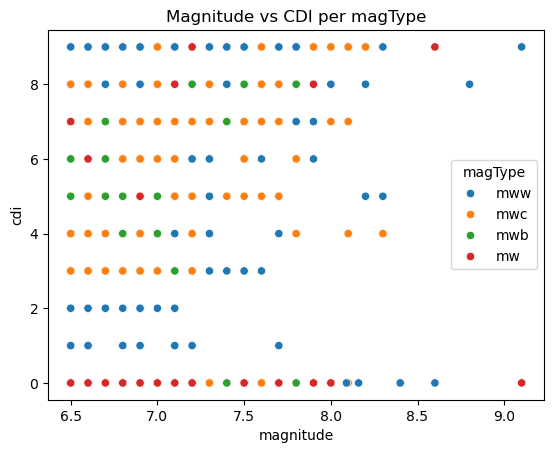

In [56]:
sns.scatterplot(data=df2, x='magnitude', y='cdi', hue='magType')
plt.title('Magnitude vs CDI per magType')
plt.show()

In [57]:
avg_residual = df2.groupby('magType')['difference'].mean()
avg_residual
#This gives us on average how far off each magtype is to the actual strength felt by humans (cdi)

magType
mw    -5.001961
mwb   -5.298000
mwc   -4.873795
mww   -1.713645
Name: difference, dtype: float64

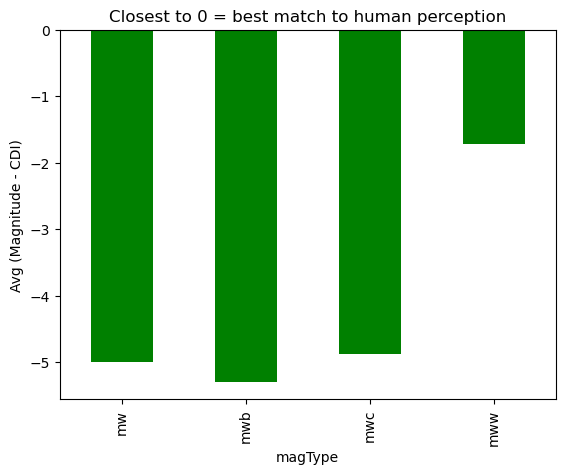

In [58]:
#Now let's create a bar chart for it, with the smallest bar (Closest to 0) Declared as the best magtype
avg_residual.plot(kind='bar', color='green')
plt.ylabel('Avg (Magnitude - CDI)')
plt.title('Closest to 0 = best match to human perception')
plt.show()

#closest to 0 will be the best

### Answer to Question 3: Without a doubt, mww is the best magtype for measuring earthquake magnitudes

# Question 4: What are the Top 10 most dangerous countries (Countries with the biggest mean for magnitudes)?


In [59]:
y=df.groupby('country')['magnitude'].mean().sort_values(ascending=False).head(10)
y

country
Samoa                         8.100000
Indian Ocean                  7.900000
Jamaica                       7.700000
Martinique                    7.400000
Iraq                          7.300000
Pakistan                      7.280000
Egypt                         7.200000
People's Republic of China    7.200000
Peru                          7.200000
Honduras                      7.166667
Name: magnitude, dtype: float64

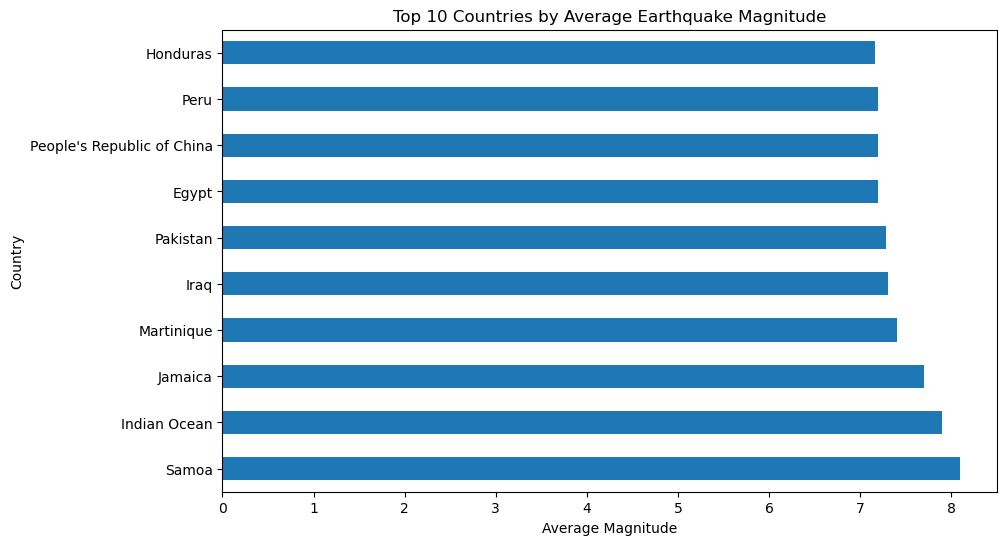

In [60]:
plt.figure(figsize=(10,6))

y.plot(kind='barh')

plt.title("Top 10 Countries by Average Earthquake Magnitude")
plt.xlabel("Average Magnitude")
plt.ylabel("Country")

plt.show()

### Answer to question 4: Samoa has the most dangerous earthquakes

# Extra Question (5): Which land types/features have higher magnitudes on average?

In [61]:
import re

df['feature'] = df['location'].str.extract(
    r'(island|peninsula|border)',
    flags=re.I
)
df['feature'] = df['feature'].fillna('others/normal')
df.iloc[50:100]

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,location,continent,country,AlertEncoded,year,Earthquake Score,mag_category,depth_category,mag_bin,feature
50,M 6.6 - south of the Kermadec Islands,6.6,2022-08-14 13:44:00,7,6,green,1,672,68,5.293000,...,the Kermadec Islands,Oceania,New Zealand,1,2022,Strong,6-7,Shallow,6.5-7,Island
51,"M 7.0 - 11 km NE of Bantay, Philippines",7.0,2022-07-27 00:43:00,9,8,yellow,1,1351,152,5.276000,...,"Bantay, Philippines",Asia,Philippines,4,2022,Strong,6-7,Shallow,6.5-7,others/normal
52,"M 6.5 - 107 km SSW of Tarauacá, Brazil",6.5,2022-06-08 00:55:00,3,2,green,0,653,236,1.999000,...,"Tarauacá, Brazil",South America,Brazil,1,2022,Strong,6-7,Deep,NaN,others/normal
53,"M 7.2 - 10 km W of Azángaro, Peru",7.2,2022-05-26 12:02:00,7,5,green,1,876,144,2.494000,...,"Azángaro, Peru",South America,Peru,1,2022,Strong,7+,Intermediate,7-7.5,others/normal
54,M 6.9 -,6.9,2022-05-19 10:13:00,2,5,green,1,733,127,0.371000,...,Unknown,None,Unknown,1,2022,Strong,6-7,Shallow,6.5-7,others/normal
55,M 6.8 - 86 km NNW of San Antonio de los Cobres...,6.8,2022-05-10 23:06:00,6,5,green,1,762,162,1.505000,...,"San Antonio de los Cobres, Argentina",South America,Argentina,1,2022,Strong,6-7,Intermediate,6.5-7,others/normal
56,"M 6.6 - 55 km WSW of Masachapa, Nicaragua",6.6,2022-04-21 07:42:00,6,5,green,1,762,0,0.914000,...,"Masachapa, Nicaragua",North America,Nicaragua,1,2022,Strong,6-7,Shallow,6.5-7,others/normal
57,M 7.0 - southeast of the Loyalty Islands,7.0,2022-03-31 05:44:00,6,4,green,1,763,0,2.705000,...,the Loyalty Islands,Oceania,New Caledonia,1,2022,Strong,6-7,Shallow,6.5-7,Island
58,"M 6.9 - 284 km ESE of Tadine, New Caledonia",6.9,2022-03-30 20:56:00,6,4,green,1,738,0,2.697000,...,"Tadine, New Caledonia",Oceania,New Caledonia,1,2022,Strong,6-7,Shallow,6.5-7,others/normal
59,"M 6.7 - 65 km S of Hualien City, Taiwan",6.7,2022-03-22 17:41:00,8,7,green,1,806,0,0.289000,...,"Hualien City, Taiwan",Asia,Taiwan,1,2022,Strong,6-7,Shallow,6.5-7,others/normal


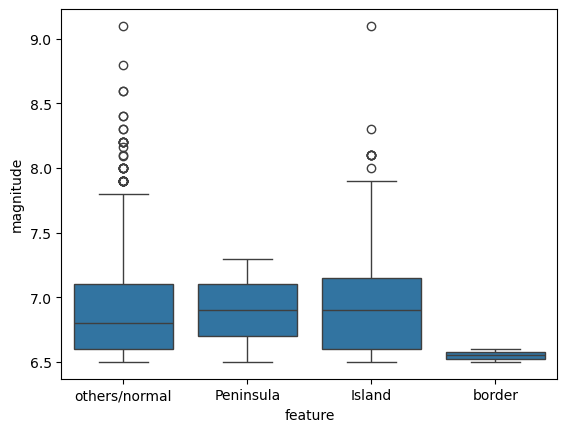

In [62]:
sns.boxplot(x='feature', y='magnitude', data=df)
plt.show()

In [63]:
feature_counts = df['feature'].value_counts()
feature_counts

feature
others/normal    885
Island           111
Peninsula          2
border             2
Name: count, dtype: int64

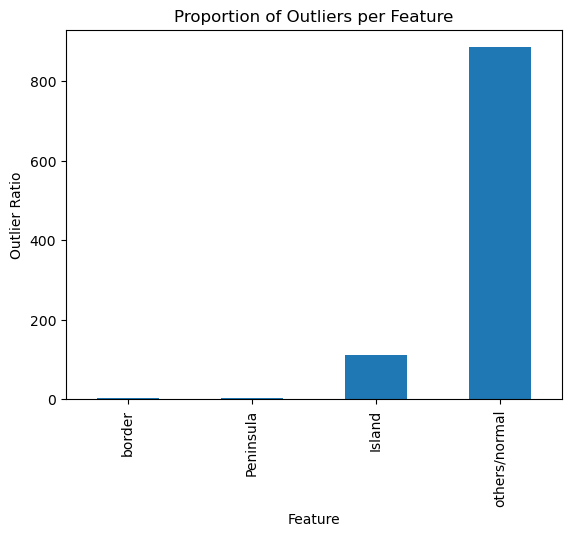

In [64]:
feature_counts.sort_values().plot(kind='bar')

plt.xlabel("Feature")
plt.ylabel("Outlier Ratio")
plt.title("Proportion of Outliers per Feature")

plt.show()

### Answer to question 5: We dont have enough info on borders. Islands and peninsulas have a higher average than normal places with others having more outliers due to being much bigger. This makes nomral places have much more possibilities for bigger outliers and rare high magnitude earthquakes. It seems that islands on average are the most dangerous to be on. (Read word document for more details)

# Question 6: Is the human perception (CDI) affected by the distance the city is from the source of the earthquake.

In [65]:
df['distance_km'] = df['title'].str.extract(r'(\d+)\s*km').astype(float)
print(df['distance_km'].isna().sum(), "earthquakes have no distance info")

#131 out of 1000 dont have the distance (minority), so we can go ahead and do the code.

131 earthquakes have no distance info


In [66]:
df['distance_km'].describe() #checking if there is some unrealistic number like 15000km for example which is greater than the diameter of the earth


count    869.000000
mean      86.002301
std       65.000018
min        0.000000
25%       33.000000
50%       73.000000
75%      123.000000
max      297.000000
Name: distance_km, dtype: float64

In [67]:
df_distcopy = df[df['distance_km'].notna().copy()]
print(f"Working with {len(df_distcopy)} earthquakes that have both distance and CDI")

#copying into a copy dataframe as to not ruin the original one. We will continue with the the distances that arent null, in other words, dropping behind the nulls

Working with 869 earthquakes that have both distance and CDI


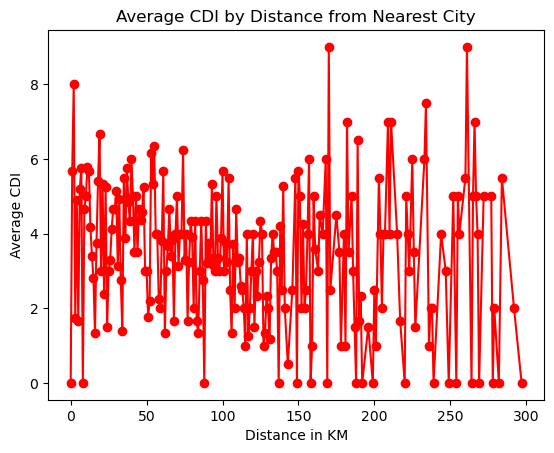

In [68]:
df_distcopy.groupby('distance_km')['cdi'].mean().plot(kind='line', marker='o', color='red')
plt.title("Average CDI by Distance from Nearest City")
plt.xlabel("Distance in KM")
plt.ylabel("Average CDI")
plt.show()

### Answer to question 6: It is obvious that the line graph above is very random. This means that the distance an earthquake is from the city has no effect on whether the humans there felt it stronger or weaker. Perhaps the magnitude has adds a factor to what the humans feel.

# _______________________________________________________________________________________

# Ahmed Gamal 247546's Visualization 

## Ahmed Gamal Questions phase one:

### 1. Does the density and distribution of seismic monitoring stations vary by region, and are certain geographic areas better equipped with earthquake detection coverage than others?
### 2. Do earthquakes that trigger tsunami warnings operate under a distinct alert classification system compared to those categorized as standard seismic events?
### 3. how does data quality change over time and have earthquake detection improved the last 27 years

In [69]:
df.head(2)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,continent,country,AlertEncoded,year,Earthquake Score,mag_category,depth_category,mag_bin,feature,distance_km
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,114,7.177,...,Oceania,Vanuatu,1,2023,Strong,6-7,Intermediate,NaN,others/normal,42.0
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,92,0.679,...,North America,El Salvador,4,2023,Strong,6-7,Shallow,NaN,others/normal,43.0


# Question 1:
## Does the density and distribution of seismic monitoring stations vary by region, and are certain geographic areas better equipped with earthquake detection coverage than others?

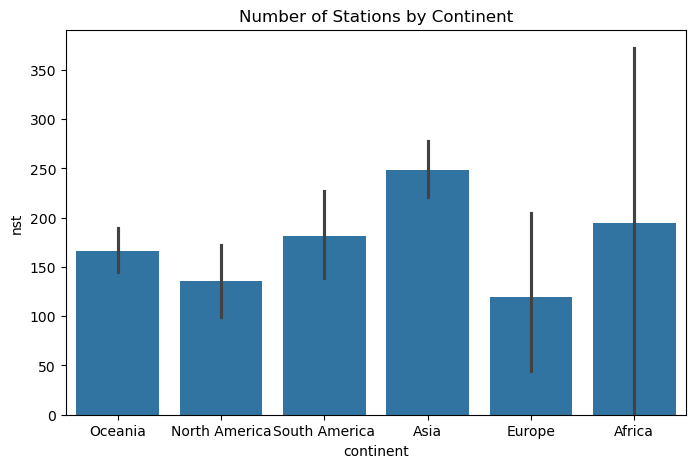

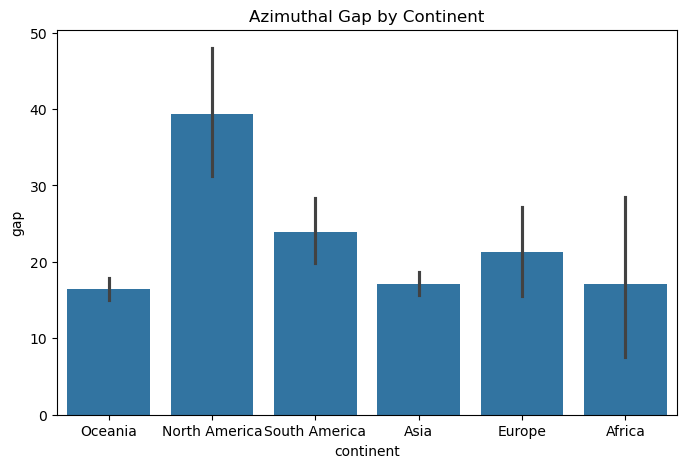

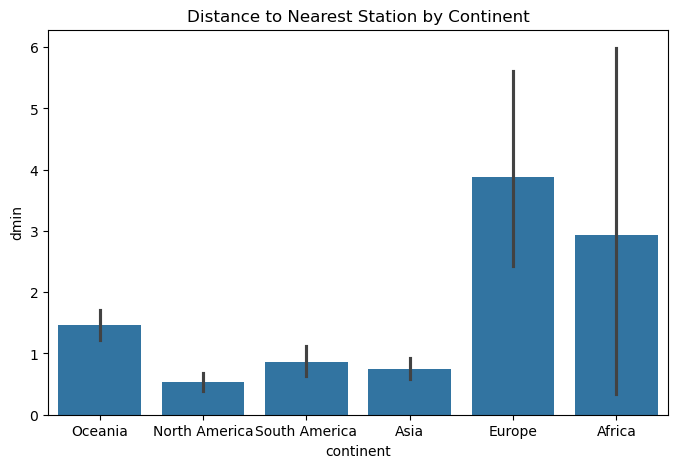

In [70]:
# Plot 1: NST
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="continent", y="nst")
plt.title("Number of Stations by Continent")
plt.show()

# Plot 2: GAP
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="continent", y="gap")
plt.title("Azimuthal Gap by Continent")
plt.show()

# Plot 3: DMIN
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="continent", y="dmin")
plt.title("Distance to Nearest Station by Continent")
plt.show()

# Question 2:
## Do earthquakes that trigger tsunami warnings operate under a distinct alert classification system compared to those categorized as standard seismic events?

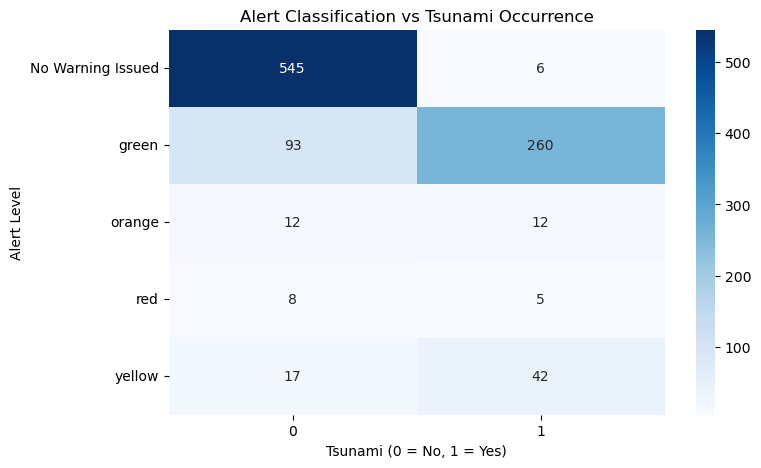

In [71]:
ct = pd.crosstab(df["alert"], df["tsunami"])

plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")

plt.title("Alert Classification vs Tsunami Occurrence")
plt.xlabel("Tsunami (0 = No, 1 = Yes)")
plt.ylabel("Alert Level")

plt.show()

# Question 3:
## How does data quality change over time and have earthquake detection improved the last 27 years

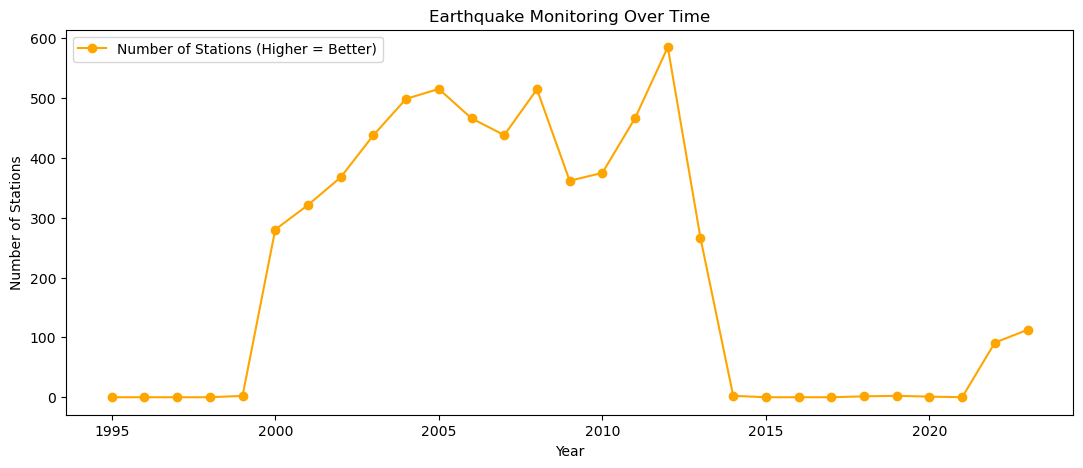

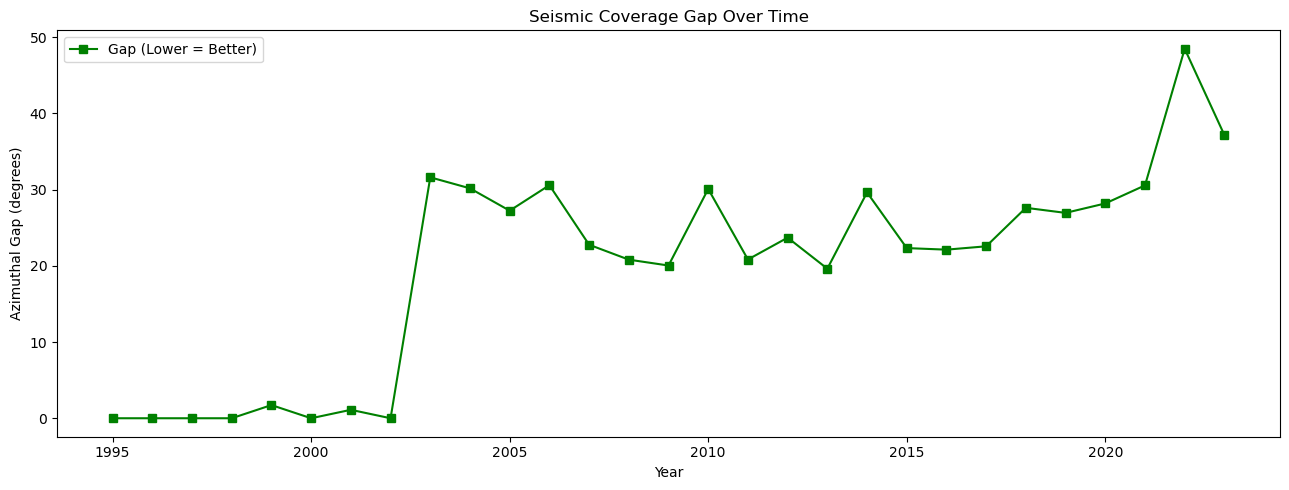

In [72]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['year'] = df['date_time'].dt.year
y = df.groupby('year')[['gap', 'nst']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(y['year'], y['nst'], label='Number of Stations (Higher = Better)', color='orange', marker='o')
ax1.set_ylabel('Number of Stations')
ax1.set_xlabel('Year')
ax1.set_title('Earthquake Monitoring Over Time')
ax1.legend(loc='upper left')

fig2, ax2 = plt.subplots(figsize=(13, 5))
ax2.plot(y['year'], y['gap'], label='Gap (Lower = Better)', color='green', marker='s')
ax2.set_ylabel('Azimuthal Gap (degrees)')
ax2.set_xlabel('Year')
ax2.set_title('Seismic Coverage Gap Over Time')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


# Karim Mohamed 240829's Questions

### Question 1: Is there a relationship between the depth of an earthquake and the number of seismic stations (NST) that detect it, and do deeper earthquakes tend to be recorded by fewer stations?

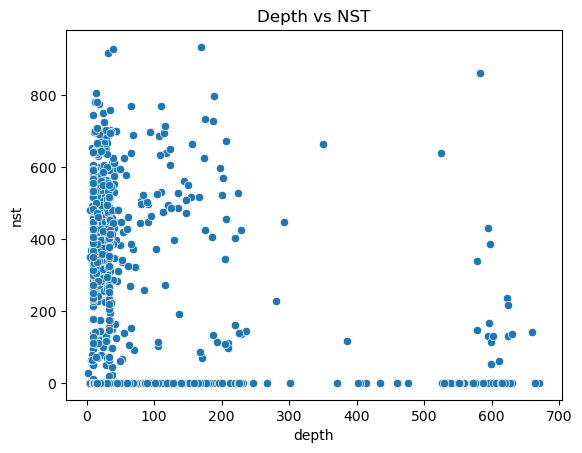

In [73]:
sns.scatterplot(x='depth', y='nst', data=df)
plt.title("Depth vs NST")
plt.show()

In [74]:
import numpy as np

corr_matrix = df[['depth','nst']].corr()
corr_value = np.corrcoef(df['depth'], df['nst'])[0,1]

corr_matrix
corr_value


np.float64(-0.10389749268038044)

### Question 2: Do earthquakes that occur closer to coastal areas have a higher probability of generating tsunami alerts compared to earthquakes that occur inland?

In [75]:
coastal = df[df['location'].str.contains("sea|ocean", case=False, na=False)]
inland = df[~df['location'].str.contains("sea|ocean", case=False, na=False)]

In [76]:
coastal_prob = np.mean(coastal['tsunami'])
inland_prob = np.mean(inland['tsunami'])

coastal_prob, inland_prob

(np.float64(0.4), np.float64(0.3242424242424242))

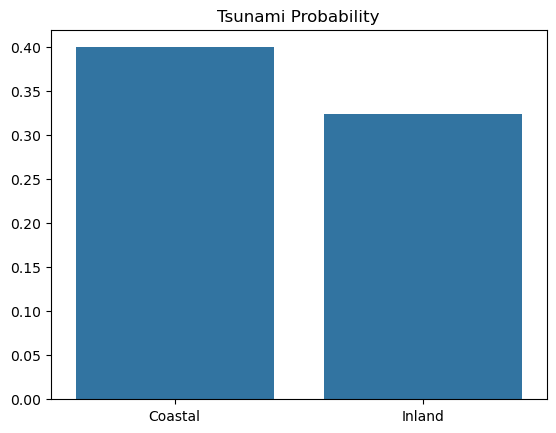

In [77]:
sns.barplot(x=['Coastal','Inland'], y=[coastal_prob, inland_prob])
plt.title("Tsunami Probability")
plt.show()

### Question 3:Has the average magnitude of detected earthquakes changed over the last 27 years, and could this change be related to improvements in earthquake monitoring technology?

In [78]:
avg_mag = df.groupby('year')['magnitude'].mean()

In [79]:
years = avg_mag.index.values
magnitudes = avg_mag.values

trend = np.polyfit(years, magnitudes, 1)
trend

array([-1.58711923e-03,  1.01320726e+01])

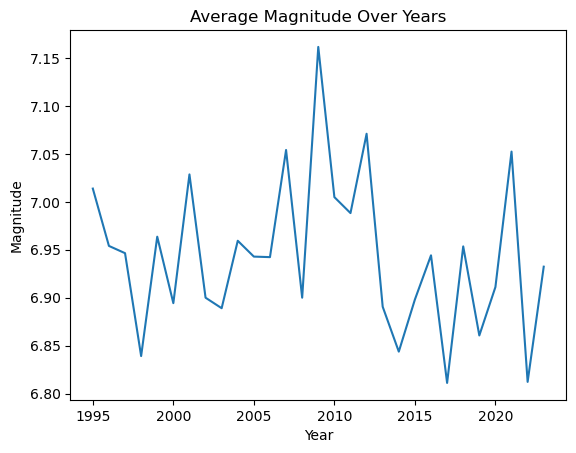

In [80]:
sns.lineplot(x=years, y=magnitudes)
plt.title("Average Magnitude Over Years")
plt.xlabel("Year")
plt.ylabel("Magnitude")
plt.show()

# Phase 2

# Data Scraping From web

In [81]:
import requests
import re
import pandas as pd
from bs4 import BeautifulSoup
import math

In [82]:
url = "https://en.wikipedia.org/wiki/List_of_deadly_earthquakes_since_1900"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

response = requests.get(url, headers=headers)


In [83]:
response_text = response.text
response_page = BeautifulSoup(response_text,'html.parser')

In [84]:
response_page.prettify()[:1000]

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-theme-clientpref-thumb-standard" dir="ltr" lang="en">\n <head>\n  <meta charset="utf-8"/>\n  <title>\n   List of deadly earthquakes since 1900 - Wikipedia\n  </title>\n  <script>\n   (function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-client

In [85]:
class_='wikitable'
table = response_page.find('table',attrs={'class':class_})

In [86]:
type(table)

bs4.element.Tag

In [87]:
# Printing the table headers to convert the table to pandas dataframe
table.find_all('th')

[<th width="22%">Origin (<a class="mw-redirect" href="/wiki/UTC" title="UTC">UTC</a>)
 </th>,
 <th width="33%">Present-day country/territory and link to Wikipedia article
 </th>,
 <th width="10%"><a href="/wiki/Latitude" title="Latitude">Lat</a>
 </th>,
 <th width="10%"><a href="/wiki/Longitude" title="Longitude">Long</a>
 </th>,
 <th width="8%">Depth (<a class="mw-redirect" href="/wiki/Km" title="Km">km</a>)
 </th>,
 <th width="6%">Magnitude
 </th>,
 <th width="9%">Secondary effects
 </th>,
 <th width="10%"><style data-mw-deduplicate="TemplateStyles:r1038841319">.mw-parser-output .tooltip-dotted{border-bottom:1px dotted;cursor:help}</style><span class="rt-commentedText tooltip tooltip-dotted" title="Preliminary Determination of Epicenters">PDE</span> shaking deaths
 </th>,
 <th width="10%"><link href="mw-data:TemplateStyles:r1038841319" rel="mw-deduplicated-inline-style"><span class="rt-commentedText tooltip tooltip-dotted" title="Preliminary Determination of Epicenters">PDE</span> to

In [88]:
# Extracting clean header names from the table
rows = table.find_all('tr')
rows[:3]

[<tr>
 <th width="22%">Origin (<a class="mw-redirect" href="/wiki/UTC" title="UTC">UTC</a>)
 </th>
 <th width="33%">Present-day country/territory and link to Wikipedia article
 </th>
 <th width="10%"><a href="/wiki/Latitude" title="Latitude">Lat</a>
 </th>
 <th width="10%"><a href="/wiki/Longitude" title="Longitude">Long</a>
 </th>
 <th width="8%">Depth (<a class="mw-redirect" href="/wiki/Km" title="Km">km</a>)
 </th>
 <th width="6%">Magnitude
 </th>
 <th width="9%">Secondary effects
 </th>
 <th width="10%"><style data-mw-deduplicate="TemplateStyles:r1038841319">.mw-parser-output .tooltip-dotted{border-bottom:1px dotted;cursor:help}</style><span class="rt-commentedText tooltip tooltip-dotted" title="Preliminary Determination of Epicenters">PDE</span> shaking deaths
 </th>
 <th width="10%"><link href="mw-data:TemplateStyles:r1038841319" rel="mw-deduplicated-inline-style"><span class="rt-commentedText tooltip tooltip-dotted" title="Preliminary Determination of Epicenters">PDE</span> tota

In [89]:
i = 0 
for row in rows:
    if i == 0: # skip the header
        i += 1
        continue
    cols = row.find_all('td')
    print(cols)
    break

[<td>1900-05-11 17:23</td>, <td>Japan</td>, <td>38.700</td>, <td>141.100</td>, <td>5</td>, <td>7.0 <a href="/wiki/Seismic_magnitude_scales#Mjma" title="Seismic magnitude scales"><abbr title="JMA mag.">M<sub>JMA</sub></abbr></a></td>, <td></td>, <td></td>, <td></td>, <td></td>, <td></td>, <td>
</td>]


In [90]:
# Separate the data into lists
date = []
country = []
latitude_wiki = []
longitude_wiki = []
depth_wiki = []
magnitude_wiki = []
secondary_effects = []
deaths = []

i = 0
for row in rows:
    if i == 0:  # skip the header
        i += 1
        continue
    cols = row.find_all('td')
    if len(cols) < 6:  # skip malformed rows
        i += 1
        continue
    date.append(re.sub(r'\[.*?\]', '', cols[0].text.strip()))
    country.append(re.sub(r'\[.*?\]', '', cols[1].text.strip()))
    latitude_wiki.append(re.sub(r'\[.*?\]', '', cols[2].text.strip()))
    longitude_wiki.append(re.sub(r'\[.*?\]', '', cols[3].text.strip()))
    depth_wiki.append(re.sub(r'\[.*?\]', '', cols[4].text.strip()))
    magnitude_wiki.append(re.sub(r'\[.*?\]', '', cols[5].text.strip()))
    secondary_effects.append(re.sub(r'\[.*?\]', '', cols[6].text.strip()) if len(cols) > 6 else '')
    deaths.append(re.sub(r'\[.*?\]', '', cols[9].text.strip()) if len(cols) > 7 else '')
    i += 1

len(date), len(country), len(latitude_wiki), len(longitude_wiki), len(depth_wiki), len(magnitude_wiki)

(1354, 1354, 1354, 1354, 1354, 1354)

In [91]:
# Create the DataFrame
scraped_df = pd.DataFrame({
    'date':              date,
    'country':           country,
    'latitude_wiki':     latitude_wiki,
    'longitude_wiki':    longitude_wiki,
    'depth_wiki':        depth_wiki,
    'magnitude_wiki':    magnitude_wiki,
    'secondary_effects': secondary_effects,
    'deaths':            deaths
})


scraped_df.head()

,date,country,latitude_wiki,longitude_wiki,depth_wiki,magnitude_wiki,secondary_effects,deaths
0,1900-05-11 17:23,Japan,38.700,141.100,5,7.0 MJMA,,
1,1900-07-12 06:25,Turkey,40.300,43.100,,5.9 Muk,,140
2,1900-10-29 09:11,Venezuela (see 1900 San Narciso earthquake),11.000,-66.000,0,7.7 Mw,,
3,1901-02-15 00:00,China,26.000,100.100,0,6.5 Ms,,
4,1901-03-31 07:11,Bulgaria,43.400,28.700,,6.4 Muk,,4


In [92]:
scraped_df.tail()

,date,country,latitude_wiki,longitude_wiki,depth_wiki,magnitude_wiki,secondary_effects,deaths
1349,2024-1-23 18:09,China (See 2024 Uqturpan earthquake),,,,7.0,,3
1350,2024-4-2 7:58,Taiwan (See 2024 Hualien earthquake),,,,7.4,,19
1351,2024-12-17 1:47,Vanuatu (See 2024 Port Vila earthquake),,,,7.3,,14
1352,2025-1-7 09:05,China (See 2025 Tibet earthquake),,,,7.1,,128
1353,2025-3-28 12:50,"Myanmar, Thailand (See 2025 Myanmar earthquake)",,,,7.7,,2610


In [93]:
scraped_df=scraped_df.rename(columns={"latitude_wiki":"latitude"})
scraped_df=scraped_df.rename(columns={"longitude_wiki":"longitude"})
scraped_df=scraped_df.rename(columns={"depth_wiki":"depth"})
scraped_df=scraped_df.rename(columns={"secondary_effects":"tsunami"})
scraped_df=scraped_df.rename(columns={"magnitude_wiki":"magnitude"})

scraped_df.head()

,date,country,latitude,longitude,depth,magnitude,tsunami,deaths
0,1900-05-11 17:23,Japan,38.700,141.100,5,7.0 MJMA,,
1,1900-07-12 06:25,Turkey,40.300,43.100,,5.9 Muk,,140
2,1900-10-29 09:11,Venezuela (see 1900 San Narciso earthquake),11.000,-66.000,0,7.7 Mw,,
3,1901-02-15 00:00,China,26.000,100.100,0,6.5 Ms,,
4,1901-03-31 07:11,Bulgaria,43.400,28.700,,6.4 Muk,,4


In [94]:
scraped_df["magnitude"] = scraped_df["magnitude"].astype(str)
scraped_df[["mag_value", "mag_type"]] = scraped_df["magnitude"].str.extract(r'(\d+\.?\d*)\s*([A-Za-z]+)')
scraped_df.head()

,date,country,latitude,longitude,depth,magnitude,tsunami,deaths,mag_value,mag_type
0,1900-05-11 17:23,Japan,38.700,141.100,5,7.0 MJMA,,,7.0,MJMA
1,1900-07-12 06:25,Turkey,40.300,43.100,,5.9 Muk,,140,5.9,Muk
2,1900-10-29 09:11,Venezuela (see 1900 San Narciso earthquake),11.000,-66.000,0,7.7 Mw,,,7.7,Mw
3,1901-02-15 00:00,China,26.000,100.100,0,6.5 Ms,,,6.5,Ms
4,1901-03-31 07:11,Bulgaria,43.400,28.700,,6.4 Muk,,4,6.4,Muk


In [95]:
scraped_df.dtypes

date         object
country      object
latitude     object
longitude    object
depth        object
magnitude    object
tsunami      object
deaths       object
mag_value    object
mag_type     object
dtype: object

In [96]:
scraped_df["tsunami"] = scraped_df["tsunami"].astype(str).str.contains("T").astype(int)

In [97]:
scraped_df["date"] = pd.to_datetime(scraped_df["date"], errors="coerce")
scraped_df["latitude"] = pd.to_numeric(scraped_df["latitude"], errors="coerce")
scraped_df["longitude"] = pd.to_numeric(scraped_df["longitude"], errors="coerce")
scraped_df["depth"] = pd.to_numeric(scraped_df["depth"], errors="coerce")
scraped_df["deaths"] = pd.to_numeric(scraped_df["deaths"], errors="coerce")

In [98]:
scraped_df.head()

,date,country,latitude,longitude,depth,magnitude,tsunami,deaths,mag_value,mag_type
0,1900-05-11 17:23:00,Japan,38.7,141.1,5.0,7.0 MJMA,0,NaN,7.0,MJMA
1,1900-07-12 06:25:00,Turkey,40.3,43.1,NaN,5.9 Muk,0,140.0,5.9,Muk
2,1900-10-29 09:11:00,Venezuela (see 1900 San Narciso earthquake),11.0,-66.0,0.0,7.7 Mw,0,NaN,7.7,Mw
3,1901-02-15 00:00:00,China,26.0,100.1,0.0,6.5 Ms,0,NaN,6.5,Ms
4,1901-03-31 07:11:00,Bulgaria,43.4,28.7,NaN,6.4 Muk,0,4.0,6.4,Muk


In [99]:
scraped_df["country"] = scraped_df["country"].str.split("(").str[0].str.strip()
scraped_df.head()

,date,country,latitude,longitude,depth,magnitude,tsunami,deaths,mag_value,mag_type
0,1900-05-11 17:23:00,Japan,38.7,141.1,5.0,7.0 MJMA,0,NaN,7.0,MJMA
1,1900-07-12 06:25:00,Turkey,40.3,43.1,NaN,5.9 Muk,0,140.0,5.9,Muk
2,1900-10-29 09:11:00,Venezuela,11.0,-66.0,0.0,7.7 Mw,0,NaN,7.7,Mw
3,1901-02-15 00:00:00,China,26.0,100.1,0.0,6.5 Ms,0,NaN,6.5,Ms
4,1901-03-31 07:11:00,Bulgaria,43.4,28.7,NaN,6.4 Muk,0,4.0,6.4,Muk


In [100]:
scraped_df = scraped_df.drop("magnitude", axis=1)

In [101]:
scraped_df=scraped_df.rename(columns={"mag_value":"magnitude"})
scraped_df=scraped_df.rename(columns={"mag_type":"magType"})
scraped_df.head() 

,date,country,latitude,longitude,depth,tsunami,deaths,magnitude,magType
0,1900-05-11 17:23:00,Japan,38.7,141.1,5.0,0,NaN,7.0,MJMA
1,1900-07-12 06:25:00,Turkey,40.3,43.1,NaN,0,140.0,5.9,Muk
2,1900-10-29 09:11:00,Venezuela,11.0,-66.0,0.0,0,NaN,7.7,Mw
3,1901-02-15 00:00:00,China,26.0,100.1,0.0,0,NaN,6.5,Ms
4,1901-03-31 07:11:00,Bulgaria,43.4,28.7,NaN,0,4.0,6.4,Muk


In [102]:
values = [6.9, 7.5, 7.0, 7.4, 7.3, 7.1]  
scraped_df.loc[scraped_df.index[-len(values):], "magnitude"] = values
#adding these 6 values manually because they randomly dissappeared (They are not too much so it will not take time)

In [103]:
scraped_df["title"] = "M " + scraped_df["magnitude"].astype(str)
scraped_df

,date,country,latitude,longitude,depth,tsunami,deaths,magnitude,magType,title
0,1900-05-11 17:23:00,Japan,38.7,141.1,5.0,0,NaN,7.0,MJMA,M 7.0
1,1900-07-12 06:25:00,Turkey,40.3,43.1,NaN,0,140.0,5.9,Muk,M 5.9
2,1900-10-29 09:11:00,Venezuela,11.0,-66.0,0.0,0,NaN,7.7,Mw,M 7.7
3,1901-02-15 00:00:00,China,26.0,100.1,0.0,0,NaN,6.5,Ms,M 6.5
4,1901-03-31 07:11:00,Bulgaria,43.4,28.7,NaN,0,4.0,6.4,Muk,M 6.4
...,...,...,...,...,...,...,...,...,...,...
1349,2024-01-23 18:09:00,China,NaN,NaN,NaN,0,3.0,7.5,NaN,M 7.5
1350,2024-04-02 07:58:00,Taiwan,NaN,NaN,NaN,0,19.0,7.0,NaN,M 7.0
1351,2024-12-17 01:47:00,Vanuatu,NaN,NaN,NaN,0,14.0,7.4,NaN,M 7.4
1352,2025-01-07 09:05:00,China,NaN,NaN,NaN,0,128.0,7.3,NaN,M 7.3


In [104]:
scraped_df["tsunami"].value_counts()

tsunami
0    1169
1     185
Name: count, dtype: int64

In [105]:
scraped_df.isnull().sum()

date           8
country        0
latitude      23
longitude     23
depth         98
tsunami        0
deaths       318
magnitude      3
magType        9
title          0
dtype: int64

In [106]:
scraped_df = scraped_df.dropna(subset=["date"])

In [107]:
scraped_df["depth"] = scraped_df.groupby("magType")["depth"].transform(
    lambda x: x.fillna(x.median())
)

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\2125439987.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [108]:
scraped_df.isnull().sum()

date           0
country        0
latitude      23
longitude     23
depth          8
tsunami        0
deaths       311
magnitude      2
magType        8
title          0
dtype: int64

In [109]:
scraped_df["deaths"] = scraped_df["deaths"].fillna(0)

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\3065277714.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [110]:
scraped_df["magType"] = scraped_df["magType"].fillna(scraped_df["magType"].mode()[0])

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\898406862.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [111]:
scraped_df[scraped_df["longitude"].isnull()]

,date,country,latitude,longitude,depth,tsunami,deaths,magnitude,magType,title
412,1963-07-26 04:17:00,North Macedonia,NaN,NaN,17.95,0,0.0,6.1,Mw,M 6.1
439,1966-04-25 23:22:00,Uzbekistan,NaN,NaN,10.00,0,0.0,5,ML,M 5
1319,2008-10-06 16:30:00,China,NaN,NaN,17.95,0,0.0,6.4,Mw,M 6.4
1320,2008-10-28 23:09:00,Pakistan,NaN,NaN,17.95,0,0.0,6.4,Mw,M 6.4
1323,2009-07-09 11:19:00,China,NaN,NaN,17.95,0,0.0,5.7,Mw,M 5.7
1324,2009-08-10 20:07:00,Japan,NaN,NaN,17.95,0,0.0,6.4,Mw,M 6.4
1325,2009-09-02 07:55:00,Indonesia,NaN,NaN,17.95,0,0.0,7.0,Mw,M 7.0
1326,2009-09-29 17:48:00,Samoa,NaN,NaN,8.10,0,0.0,8.1,Mw,M 8.1
1327,2009-09-30 10:16:00,Indonesia,NaN,NaN,17.95,0,0.0,7.6,Mw,M 7.6
1330,2010-03-08 02:32:00,Turkey,NaN,NaN,17.95,0,0.0,6.1,Mw,M 6.1


In [112]:
country_coords = {
    "Japan": (36.2048, 138.2529),
    "China": (35.8617, 104.1954),
    "Turkey": (38.9637, 35.2433),
    "Indonesia": (-0.7893, 113.9213),
    "Chile": (-35.6751, -71.5430),
    "Pakistan": (30.3753, 69.3451),
    "New Zealand": (-40.9006, 174.8860),
    "Morocco": (31.7917, -7.0926),
    "Taiwan": (23.6978, 120.9605),
    "Vanuatu": (-15.3767, 166.9592),
    "Samoa": (-13.7590, -172.1046),
    "Uzbekistan": (41.3775, 64.5853),
    "North Macedonia": (41.6086, 21.7453),
    "Myanmar": (21.9162, 95.9560)
}

In [113]:
def fill_coords(row):
    if pd.isna(row["latitude"]) or pd.isna(row["longitude"]):
        coords = country_coords.get(row["country"])
        if coords:
            return pd.Series(coords)
    return pd.Series([row["latitude"], row["longitude"]])

scraped_df[["latitude", "longitude"]] = scraped_df.apply(fill_coords, axis=1)

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\409226496.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [114]:
scraped_df.isnull().sum()

date         0
country      0
latitude     1
longitude    1
depth        8
tsunami      0
deaths       0
magnitude    2
magType      0
title        0
dtype: int64

In [115]:
scraped_df = scraped_df.dropna()

In [116]:
scraped_df.isnull().sum()

date         0
country      0
latitude     0
longitude    0
depth        0
tsunami      0
deaths       0
magnitude    0
magType      0
title        0
dtype: int64

# Now time to merge

In [117]:
# First drop the artificial columns we created in phase 1
df.drop([
    "AlertEncoded",
    "year",
    "Earthquake Score",
    "mag_category",
    "depth_category",
    "mag_bin",
    "feature",
    "distance_km"
], axis=1, inplace=True)

In [118]:
scraped_df=scraped_df.rename(columns={"date":"date_time"}) #So that they both match (date column in both datasets)

In [119]:
scraped_df["location"] = scraped_df["country"] #This is to make a new column (location) so it matches with the original df

In [120]:
import pycountry_convert as pc

def get_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        return {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania"
        }[continent_code]
    except:
        return "Unknown"

scraped_df["continent"] = scraped_df["country"].apply(get_continent)

In [121]:
combined_df = pd.concat([df, scraped_df], ignore_index=True)
combined_df

#Merging wont work here so we concatinated (Too many nulls)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,deaths
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7.0,4.0,green,0,657.0,114.0,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,NaN
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8.0,6.0,yellow,0,775.0,92.0,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",North America,El Salvador,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7.0,5.0,green,0,899.0,70.0,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,NaN
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6.0,6.0,green,1,860.0,173.0,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",North America,United States of America,NaN
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0.0,5.0,No Warning Issued,1,820.0,79.0,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,North America,United States of America,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,M 6.9,6.9,2018-08-05 19:46:00,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Mw,31.000,-0.7893,113.9213,Indonesia,Asia,Indonesia,0.0
2334,M 7.5,7.5,2018-09-28 10:02:00,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,Mw,20.000,0.1780,119.8400,Indonesia,Asia,Indonesia,0.0
2335,M 7.0,7.0,2020-10-30 11:51:00,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,Mww,21.000,37.9180,26.7900,"Turkey, Greece",Unknown,"Turkey, Greece",0.0
2336,M 6.2,6.2,2022-06-21 21:54:00,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Mw,10.000,33.0920,69.5140,"Afghanistan, Pakistan",Unknown,"Afghanistan, Pakistan",1000.0


# Data cleaning of combined dataframe: 

In [122]:
combined_df.isnull().sum() #Checking nulls so that we start data cleaning

title           0
magnitude       0
date_time       0
cdi          1338
mmi          1338
alert        1338
tsunami         0
sig          1338
nst          1338
dmin         1338
gap          1338
magType         0
depth           0
latitude        0
longitude       0
location        0
continent      76
country         0
deaths       1000
dtype: int64

In [123]:
combined_df.dtypes

title                object
magnitude            object
date_time    datetime64[ns]
cdi                 float64
mmi                 float64
alert                object
tsunami               int64
sig                 float64
nst                 float64
dmin                float64
gap                 float64
magType              object
depth               float64
latitude            float64
longitude           float64
location             object
continent            object
country              object
deaths              float64
dtype: object

In [124]:
combined_df["magnitude"] = combined_df["magnitude"].astype(float) #Changing magnitude from string to float

In [125]:
combined_df["mag_bin"] = pd.cut(
    combined_df["magnitude"],
    bins=[0, 5, 6, 7, 8, 10],
    labels=["<5", "5-6", "6-7", "7-8", "8+"]
)
#Making magnitude bins for the new combined df to help us with data cleaning

In [126]:
cdi_map = combined_df.groupby("mag_bin")["cdi"].median() #Computing median magnitude per bin 

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\3985399692.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [127]:
combined_df["cdi"] = combined_df["cdi"].fillna(
    combined_df["mag_bin"].map(cdi_map)
)
#fill in nulls in cdi with the median of the magnitudes of its magnitude

In [128]:
combined_df["cdi"] = combined_df["cdi"].fillna(combined_df["cdi"].median()) #Incase there were bins with no data

In [129]:
combined_df.tail(50) #Checking last 50 

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,deaths,mag_bin
2288,M 5.3,5.3,2007-11-07 04:12:00,4.0,NaN,NaN,0,NaN,NaN,NaN,NaN,Mw,71.00,9.7210,124.6470,Philippines,Asia,Philippines,0.0,5-6
2289,M 7.7,7.7,2007-11-14 15:40:00,5.0,NaN,NaN,1,NaN,NaN,NaN,NaN,Mw,40.00,-22.2470,-69.8900,Chile,South America,Chile,0.0,7-8
2290,M 6.5,6.5,2007-11-25 16:02:00,4.0,NaN,NaN,0,NaN,NaN,NaN,NaN,Mw,20.00,-8.2920,118.3700,Indonesia,Asia,Indonesia,0.0,6-7
2291,M 7.4,7.4,2007-11-29 19:00:00,5.0,NaN,NaN,0,NaN,NaN,NaN,NaN,Mw,156.00,14.9440,-61.2740,Martinique,North America,Martinique,0.0,7-8
2292,M 4.9,4.9,2007-12-09 02:03:00,4.0,NaN,NaN,0,NaN,NaN,NaN,NaN,mb,10.00,-15.0480,-44.2310,Brazil,South America,Brazil,0.0,<5
2293,M 6.6,6.6,2007-12-20 07:55:00,4.0,NaN,NaN,0,NaN,NaN,NaN,NaN,Mw,20.00,-39.0110,178.2910,New Zealand,Oceania,New Zealand,0.0,6-7
2294,M 4.6,4.6,2008-01-09 22:24:00,4.0,NaN,NaN,0,NaN,NaN,NaN,NaN,Mb,10.00,35.6160,-0.5700,Algeria,Africa,Algeria,0.0,<5
2295,M 6.2,6.2,2008-01-22 17:14:00,4.0,NaN,NaN,0,NaN,NaN,NaN,NaN,Mw,20.00,1.0110,97.4420,Indonesia,Asia,Indonesia,0.0,6-7
2296,M 5.9,5.9,2008-02-03 07:34:00,4.0,NaN,NaN,0,NaN,NaN,NaN,NaN,Mw,10.00,-2.2960,28.9000,Democratic Republic of the Congo,Africa,Democratic Republic of the Congo,0.0,5-6
2297,M 4.3,4.3,2008-02-06 06:09:00,4.0,NaN,NaN,0,NaN,NaN,NaN,NaN,mb,10.00,23.4330,87.1110,India,Asia,India,0.0,<5


In [130]:
mmi_map = combined_df.groupby("magnitude")["mmi"].median() #Doing same process of cfi for mmi 

combined_df["mmi"] = combined_df["mmi"].fillna(combined_df["magnitude"].map(mmi_map) )

combined_df["mmi"] = combined_df["mmi"].fillna(combined_df["mmi"].median() )

###########################################################################################################################
sig_map = combined_df.groupby("magnitude")["sig"].mean() #Same process here alsonfor sig but with mean

combined_df["sig"] = combined_df["sig"].fillna( combined_df["magnitude"].map(sig_map))

combined_df["sig"] = combined_df["sig"].fillna(combined_df["sig"].mean())

##############################################################################################################################
gap_map = combined_df.groupby("magnitude")["gap"].mean() #Same process here also

combined_df["gap"] = combined_df["gap"].fillna(combined_df["magnitude"].map(gap_map) )

combined_df["gap"] = combined_df["gap"].fillna(combined_df["gap"].median())

In [131]:
combined_df.tail(50)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,deaths,mag_bin
2288,M 5.3,5.3,2007-11-07 04:12:00,4.0,6.0,NaN,0,876.918617,NaN,NaN,19.085714,Mw,71.00,9.7210,124.6470,Philippines,Asia,Philippines,0.0,5-6
2289,M 7.7,7.7,2007-11-14 15:40:00,5.0,7.0,NaN,1,1038.913043,NaN,NaN,14.365217,Mw,40.00,-22.2470,-69.8900,Chile,South America,Chile,0.0,7-8
2290,M 6.5,6.5,2007-11-25 16:02:00,4.0,6.0,NaN,0,704.296970,NaN,NaN,25.063576,Mw,20.00,-8.2920,118.3700,Indonesia,Asia,Indonesia,0.0,6-7
2291,M 7.4,7.4,2007-11-29 19:00:00,5.0,7.0,NaN,0,991.450000,NaN,NaN,20.405000,Mw,156.00,14.9440,-61.2740,Martinique,North America,Martinique,0.0,7-8
2292,M 4.9,4.9,2007-12-09 02:03:00,4.0,6.0,NaN,0,876.918617,NaN,NaN,19.085714,mb,10.00,-15.0480,-44.2310,Brazil,South America,Brazil,0.0,<5
2293,M 6.6,6.6,2007-12-20 07:55:00,4.0,6.0,NaN,0,730.227273,NaN,NaN,19.085714,Mw,20.00,-39.0110,178.2910,New Zealand,Oceania,New Zealand,0.0,6-7
2294,M 4.6,4.6,2008-01-09 22:24:00,4.0,6.0,NaN,0,876.918617,NaN,NaN,19.085714,Mb,10.00,35.6160,-0.5700,Algeria,Africa,Algeria,0.0,<5
2295,M 6.2,6.2,2008-01-22 17:14:00,4.0,6.0,NaN,0,876.918617,NaN,NaN,19.085714,Mw,20.00,1.0110,97.4420,Indonesia,Asia,Indonesia,0.0,6-7
2296,M 5.9,5.9,2008-02-03 07:34:00,4.0,6.0,NaN,0,876.918617,NaN,NaN,19.085714,Mw,10.00,-2.2960,28.9000,Democratic Republic of the Congo,Africa,Democratic Republic of the Congo,0.0,5-6
2297,M 4.3,4.3,2008-02-06 06:09:00,4.0,6.0,NaN,0,876.918617,NaN,NaN,19.085714,mb,10.00,23.4330,87.1110,India,Asia,India,0.0,<5


In [132]:
import numpy as np

combined_df["dmin"] = combined_df["dmin"].replace(0, np.nan) #Mistake was done with dmin data cleaning, returning the nulls to do data cleaning again

In [133]:
combined_df["dmin"] = combined_df["dmin"].fillna( combined_df.groupby("country")["dmin"].transform("median") ) #fill woth median of that country (transform does it one by one)
combined_df["dmin"] = combined_df["dmin"].fillna( combined_df["dmin"].median() ) #if there isnt a country for it, just fill it with the global median

In [134]:
combined_df

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,deaths,mag_bin
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7.0,4.0,green,0,657.000000,114.0,7.177000,25.000000,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,NaN,6-7
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8.0,6.0,yellow,0,775.000000,92.0,0.679000,40.000000,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",North America,El Salvador,NaN,6-7
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7.0,5.0,green,0,899.000000,70.0,1.634000,28.000000,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,NaN,6-7
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6.0,6.0,green,1,860.000000,173.0,0.907000,36.000000,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",North America,United States of America,NaN,7-8
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0.0,5.0,No Warning Issued,1,820.000000,79.0,0.879451,172.800000,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,North America,United States of America,NaN,7-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,M 6.9,6.9,2018-08-05 19:46:00,4.0,6.0,NaN,0,841.325843,NaN,1.947500,23.723596,Mw,31.000,-0.7893,113.9213,Indonesia,Asia,Indonesia,0.0,6-7
2334,M 7.5,7.5,2018-09-28 10:02:00,5.0,7.0,NaN,1,1045.642857,NaN,1.947500,14.503571,Mw,20.000,0.1780,119.8400,Indonesia,Asia,Indonesia,0.0,7-8
2335,M 7.0,7.0,2020-10-30 11:51:00,4.0,7.0,NaN,1,874.328571,NaN,1.970000,18.528571,Mww,21.000,37.9180,26.7900,"Turkey, Greece",Unknown,"Turkey, Greece",0.0,6-7
2336,M 6.2,6.2,2022-06-21 21:54:00,4.0,6.0,NaN,0,876.918617,NaN,1.970000,19.085714,Mw,10.000,33.0920,69.5140,"Afghanistan, Pakistan",Unknown,"Afghanistan, Pakistan",1000.0,6-7


In [135]:
combined_df["nst"] = combined_df["nst"].fillna(combined_df.groupby("country")["nst"].transform("median")) #fill woth median of that country (transform does it one by one)
combined_df["nst"] = combined_df["nst"].fillna( combined_df["nst"].median() ) #if there isnt a country for it, just fill it with the global median

In [136]:
combined_df.tail(50)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,deaths,mag_bin
2288,M 5.3,5.3,2007-11-07 04:12:00,4.0,6.0,NaN,0,876.918617,0.0,2.8215,19.085714,Mw,71.00,9.7210,124.6470,Philippines,Asia,Philippines,0.0,5-6
2289,M 7.7,7.7,2007-11-14 15:40:00,5.0,7.0,NaN,1,1038.913043,0.0,0.8170,14.365217,Mw,40.00,-22.2470,-69.8900,Chile,South America,Chile,0.0,7-8
2290,M 6.5,6.5,2007-11-25 16:02:00,4.0,6.0,NaN,0,704.296970,271.5,1.9475,25.063576,Mw,20.00,-8.2920,118.3700,Indonesia,Asia,Indonesia,0.0,6-7
2291,M 7.4,7.4,2007-11-29 19:00:00,5.0,7.0,NaN,0,991.450000,663.0,1.9700,20.405000,Mw,156.00,14.9440,-61.2740,Martinique,North America,Martinique,0.0,7-8
2292,M 4.9,4.9,2007-12-09 02:03:00,4.0,6.0,NaN,0,876.918617,0.0,1.9990,19.085714,mb,10.00,-15.0480,-44.2310,Brazil,South America,Brazil,0.0,<5
2293,M 6.6,6.6,2007-12-20 07:55:00,4.0,6.0,NaN,0,730.227273,0.0,0.9985,19.085714,Mw,20.00,-39.0110,178.2910,New Zealand,Oceania,New Zealand,0.0,6-7
2294,M 4.6,4.6,2008-01-09 22:24:00,4.0,6.0,NaN,0,876.918617,534.0,1.9700,19.085714,Mb,10.00,35.6160,-0.5700,Algeria,Africa,Algeria,0.0,<5
2295,M 6.2,6.2,2008-01-22 17:14:00,4.0,6.0,NaN,0,876.918617,271.5,1.9475,19.085714,Mw,20.00,1.0110,97.4420,Indonesia,Asia,Indonesia,0.0,6-7
2296,M 5.9,5.9,2008-02-03 07:34:00,4.0,6.0,NaN,0,876.918617,70.5,1.9700,19.085714,Mw,10.00,-2.2960,28.9000,Democratic Republic of the Congo,Africa,Democratic Republic of the Congo,0.0,5-6
2297,M 4.3,4.3,2008-02-06 06:09:00,4.0,6.0,NaN,0,876.918617,383.0,2.2930,19.085714,mb,10.00,23.4330,87.1110,India,Asia,India,0.0,<5


In [137]:
combined_df["cdi"] = combined_df["cdi"].replace(0, np.nan) #For same reason cdi didnt also fully work

In [138]:
combined_df["cdi"] = combined_df["cdi"].fillna(combined_df.groupby("magnitude")["cdi"].transform("median"))
combined_df["cdi"] = combined_df["cdi"].fillna(combined_df["cdi"].median() )
#Giving cdi the median for magnitude group

In [139]:
combined_df["alert"] = combined_df["alert"].fillna("no warning issued") #Can't get means or patterns, makes sense to just say:
#No warning issued

In [140]:
combined_df #Checking...

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,deaths,mag_bin
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7.0,4.0,green,0,657.000000,114.0,7.177000,25.000000,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,NaN,6-7
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8.0,6.0,yellow,0,775.000000,92.0,0.679000,40.000000,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",North America,El Salvador,NaN,6-7
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7.0,5.0,green,0,899.000000,70.0,1.634000,28.000000,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,NaN,6-7
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6.0,6.0,green,1,860.000000,173.0,0.907000,36.000000,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",North America,United States of America,NaN,7-8
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,5.0,5.0,No Warning Issued,1,820.000000,79.0,0.879451,172.800000,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,North America,United States of America,NaN,7-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,M 6.9,6.9,2018-08-05 19:46:00,4.0,6.0,no warning issued,0,841.325843,271.5,1.947500,23.723596,Mw,31.000,-0.7893,113.9213,Indonesia,Asia,Indonesia,0.0,6-7
2334,M 7.5,7.5,2018-09-28 10:02:00,5.0,7.0,no warning issued,1,1045.642857,271.5,1.947500,14.503571,Mw,20.000,0.1780,119.8400,Indonesia,Asia,Indonesia,0.0,7-8
2335,M 7.0,7.0,2020-10-30 11:51:00,4.0,7.0,no warning issued,1,874.328571,70.5,1.970000,18.528571,Mww,21.000,37.9180,26.7900,"Turkey, Greece",Unknown,"Turkey, Greece",0.0,6-7
2336,M 6.2,6.2,2022-06-21 21:54:00,4.0,6.0,no warning issued,0,876.918617,70.5,1.970000,19.085714,Mw,10.000,33.0920,69.5140,"Afghanistan, Pakistan",Unknown,"Afghanistan, Pakistan",1000.0,6-7


In [141]:
 #Checking to see if there is any other cleaning we need to do
combined_df.isnull().sum()

title           0
magnitude       0
date_time       0
cdi             0
mmi             0
alert           0
tsunami         0
sig             0
nst             0
dmin            0
gap             0
magType         0
depth           0
latitude        0
longitude       0
location        0
continent      76
country         0
deaths       1000
mag_bin         0
dtype: int64

In [142]:
combined_df['deaths'] = combined_df['deaths'].fillna(-0) #Not specified so assume 0
combined_df['continent'] = combined_df['continent'].fillna('not identified/island') #If it didnt convert to a continent, that means its either an island in the middle 
#of the ocean or not specified

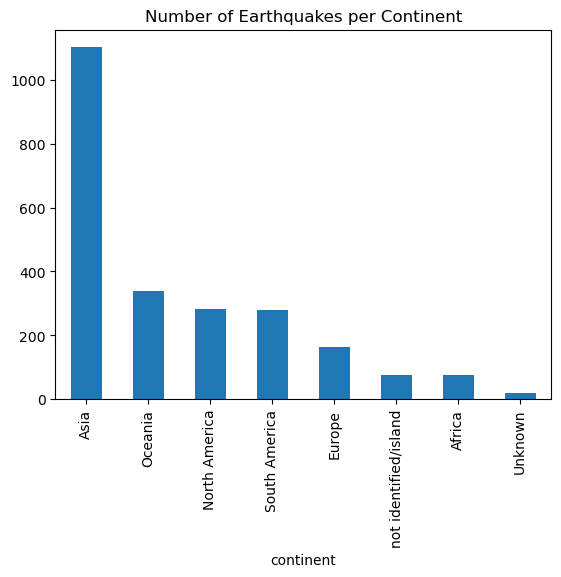

In [210]:
combined_df['continent'].value_counts().plot(kind='bar')
plt.title("Number of Earthquakes per Continent")
plt.show()

#seeing distribution of continents

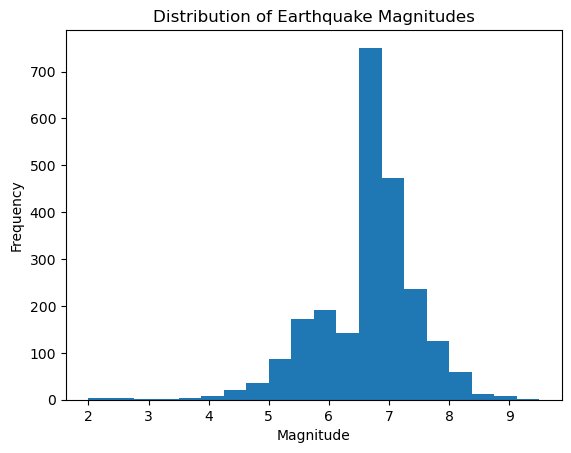

In [212]:
#Magnitude distribution:
plt.hist(combined_df['magnitude'], bins=20)
plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

In [143]:
combined_df #Final check

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country,deaths,mag_bin
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7.0,4.0,green,0,657.000000,114.0,7.177000,25.000000,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,0.0,6-7
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8.0,6.0,yellow,0,775.000000,92.0,0.679000,40.000000,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",North America,El Salvador,0.0,6-7
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7.0,5.0,green,0,899.000000,70.0,1.634000,28.000000,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,0.0,6-7
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6.0,6.0,green,1,860.000000,173.0,0.907000,36.000000,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",North America,United States of America,0.0,7-8
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,5.0,5.0,No Warning Issued,1,820.000000,79.0,0.879451,172.800000,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,North America,United States of America,0.0,7-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,M 6.9,6.9,2018-08-05 19:46:00,4.0,6.0,no warning issued,0,841.325843,271.5,1.947500,23.723596,Mw,31.000,-0.7893,113.9213,Indonesia,Asia,Indonesia,0.0,6-7
2334,M 7.5,7.5,2018-09-28 10:02:00,5.0,7.0,no warning issued,1,1045.642857,271.5,1.947500,14.503571,Mw,20.000,0.1780,119.8400,Indonesia,Asia,Indonesia,0.0,7-8
2335,M 7.0,7.0,2020-10-30 11:51:00,4.0,7.0,no warning issued,1,874.328571,70.5,1.970000,18.528571,Mww,21.000,37.9180,26.7900,"Turkey, Greece",Unknown,"Turkey, Greece",0.0,6-7
2336,M 6.2,6.2,2022-06-21 21:54:00,4.0,6.0,no warning issued,0,876.918617,70.5,1.970000,19.085714,Mw,10.000,33.0920,69.5140,"Afghanistan, Pakistan",Unknown,"Afghanistan, Pakistan",1000.0,6-7


# Hypothesis Testing

## H0: Null Hypothesis: Magnitude is not related to whether a tsunami happens or not (Variables are independant) at 5% Significance Level

## H1: Alternative Hypothesis: Magnitude is related to whether a tsunami happens or not (Variables are dependedant) at 5% Significance level

In [144]:
df_hypo = combined_df[["magnitude", "tsunami"]].copy()
df_hypo.head()
#Making a new df with just the 2 variables we want to compare

,magnitude,tsunami
0,6.5,0
1,6.5,0
2,6.6,0
3,7.2,1
4,7.3,1


In [145]:
df_hypo["magnitude"].agg(["min", "max"])

min    2.0
max    9.5
Name: magnitude, dtype: float64

In [146]:
df_hypo["mag_bin"] = pd.cut(df_hypo["magnitude"], bins=[0, 5, 6, 7, 8, 10], labels=["<5", "5-6", "6-7", "7-8", "8+"]) 
#doing binning to split them into catgories

### Tsunami is either 0 or 1


C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\774754869.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



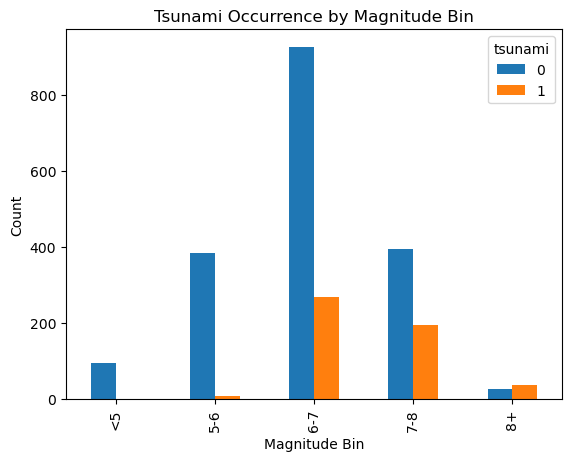

In [147]:
#Plotting sample
table = df_hypo.groupby(["mag_bin", "tsunami"]).size().unstack()

table.plot(kind="bar")

plt.title("Tsunami Occurrence by Magnitude Bin")
plt.xlabel("Magnitude Bin")
plt.ylabel("Count")
plt.show()

In [148]:
rows=df_hypo['mag_bin'].unique()
cols=df_hypo['tsunami'].unique()

In [149]:
matrix=[]
for i in rows:
    l=[]
    for j in cols:
        l.append(len(df_hypo[(df_hypo['mag_bin']==i) & (df_hypo['tsunami']==j)]))
    matrix.append(l)
matrix

[[926, 269], [395, 195], [26, 38], [385, 8], [96, 0]]

In [150]:
pd.DataFrame(matrix,index=rows,columns=cols)

,0,1
6-7,926,269
7-8,395,195
8+,26,38
5-6,385,8
<5,96,0


In [151]:
tsunamis=pd.DataFrame(matrix,index=rows,columns=cols)

In [152]:
tsunamis.sum() #seeing the complete sum of everything

0    1828
1     510
dtype: int64

In [153]:
tsunamis.loc['Total']=tsunamis.sum()
tsunamis

,0,1
6-7,926,269
7-8,395,195
8+,26,38
5-6,385,8
<5,96,0
Total,1828,510


In [154]:
tsunamis['Total']=tsunamis.sum(axis=1)
tsunamis

,0,1,Total
6-7,926,269,1195
7-8,395,195,590
8+,26,38,64
5-6,385,8,393
<5,96,0,96
Total,1828,510,2338


In [155]:
matrix2=[]
for i in rows:
    l=[]
    for j in cols:
        v=(tsunamis.loc[i,'Total']*tsunamis.loc['Total',j])/tsunamis.loc['Total','Total']
        l.append(v)
    matrix2.append(l)
matrix2
#This is getting the expected values as a matrix

[[np.float64(934.3284858853721), np.float64(260.6715141146279)],
 [np.float64(461.3002566295979), np.float64(128.69974337040205)],
 [np.float64(50.039349871685204), np.float64(13.960650128314798)],
 [np.float64(307.27288280581695), np.float64(85.72711719418307)],
 [np.float64(75.0590248075278), np.float64(20.940975192472198)]]

In [156]:
expectedvalues=pd.DataFrame(matrix2,index=rows,columns=cols)
expectedvalues

,0,1
6-7,934.328486,260.671514
7-8,461.300257,128.699743
8+,50.039350,13.960650
5-6,307.272883,85.727117
<5,75.059025,20.940975


In [157]:
tsunamis.drop('Total',axis=1,inplace=True)
tsunamis.drop('Total',axis=0,inplace=True)

#Dropping all totals (Rows and columns as to not confuse us when comparing

In [158]:
tsunamis


,0,1
6-7,926,269
7-8,395,195
8+,26,38
5-6,385,8
<5,96,0


In [159]:
expectedvalues
#Displaying both to compare between them

,0,1
6-7,934.328486,260.671514
7-8,461.300257,128.699743
8+,50.039350,13.960650
5-6,307.272883,85.727117
<5,75.059025,20.940975


## Now let calculate the degree of freedom: (r-1)(c-1)

In [160]:
#Getting the shape to know the rows and columns:
expectedvalues.shape

(5, 2)

In [161]:
DegreeOfFreedom = ( 5 - 1 ) * (2 - 1)
DegreeOfFreedom

4

# Now calculate the chi square

In [162]:
# summation of (observed - expected)^2/ Expected

In [163]:
tsunamis.values.flatten()

array([926, 269, 395, 195,  26,  38, 385,   8,  96,   0])

In [164]:
chiScoreTable=pd.DataFrame(tsunamis.values.flatten(),columns=['Observed'])
chiScoreTable

,Observed
0,926
1,269
2,395
3,195
4,26
5,38
6,385
7,8
8,96
9,0


In [165]:
expectedvalues.values.flatten()

array([934.32848589, 260.67151411, 461.30025663, 128.69974337,
        50.03934987,  13.96065013, 307.27288281,  85.72711719,
        75.05902481,  20.94097519])

In [166]:
chiScoreTable['Expected']=expectedvalues.values.flatten()
chiScoreTable

,Observed,Expected
0,926,934.328486
1,269,260.671514
2,395,461.300257
3,195,128.699743
4,26,50.039350
5,38,13.960650
6,385,307.272883
7,8,85.727117
8,96,75.059025
9,0,20.940975


In [167]:
#Observed - expected squared
chiScoreTable['(Obs. - Exp)^2']=(chiScoreTable['Observed']-chiScoreTable['Expected'])**2
chiScoreTable

,Observed,Expected,(Obs. - Exp)^2
0,926,934.328486,69.363677
1,269,260.671514,69.363677
2,395,461.300257,4395.724029
3,195,128.699743,4395.724029
4,26,50.039350,577.890342
5,38,13.960650,577.890342
6,385,307.272883,6041.504747
7,8,85.727117,6041.504747
8,96,75.059025,438.524442
9,0,20.940975,438.524442


In [168]:
#Observed - Expected Squared / Expected
chiScoreTable['((Obs.-Exp.)^2)/Exp']=chiScoreTable['(Obs. - Exp)^2']/chiScoreTable['Expected']
chiScoreTable

,Observed,Expected,(Obs. - Exp)^2,((Obs.-Exp.)^2)/Exp
0,926,934.328486,69.363677,0.074239
1,269,260.671514,69.363677,0.266096
2,395,461.300257,4395.724029,9.528987
3,195,128.699743,4395.724029,34.154878
4,26,50.039350,577.890342,11.548718
5,38,13.960650,577.890342,41.394229
6,385,307.272883,6041.504747,19.661692
7,8,85.727117,6041.504747,70.473672
8,96,75.059025,438.524442,5.842395
9,0,20.940975,438.524442,20.940975


In [169]:
#Now do the summation
chiScore=chiScoreTable['((Obs.-Exp.)^2)/Exp'].sum()
chiScore

np.float64(213.88588027752957)

In [170]:
# so if degree of freedom is 4 and significance level is 0.05, on the chi - table, the value is: 9.488

#To make sure:
from scipy.stats import chi2

deg_f = 4
sig = 0.05

chi2.ppf(1-sig, deg_f)

np.float64(9.487729036781154)

# 213.885 > 9.487 so we reject the null hypothesis (This means magnitude is related to whether a tsunami happens or not)

In [171]:
################################################################################################################################3

# Phase 2 Questions

# Ahmed Abousheasha 248002's Questions for Phase 2:

# Q1) What has changed over time with respect to earthquatke and frequnce after analyzing new scraped data?

In [172]:
import pandas as pd

combined_df['depth_category'] = pd.cut(
    combined_df['depth'],
    bins=[0, 70, 300, 10000],
    labels=['Shallow', 'Intermediate', 'Deep']
)

In [173]:
combined_df.head()


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,magType,depth,latitude,longitude,location,continent,country,deaths,mag_bin,depth_category
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7.0,4.0,green,0,657.0,114.0,7.177000,...,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,0.0,6-7,Intermediate
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8.0,6.0,yellow,0,775.0,92.0,0.679000,...,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",North America,El Salvador,0.0,6-7,Shallow
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7.0,5.0,green,0,899.0,70.0,1.634000,...,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,0.0,6-7,Intermediate
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6.0,6.0,green,1,860.0,173.0,0.907000,...,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",North America,United States of America,0.0,7-8,Shallow
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,5.0,5.0,No Warning Issued,1,820.0,79.0,0.879451,...,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,North America,United States of America,0.0,7-8,Shallow


In [174]:
combined_df['date_time'] = pd.to_datetime(combined_df['date_time'])
combined_df['year'] = combined_df['date_time'].dt.year

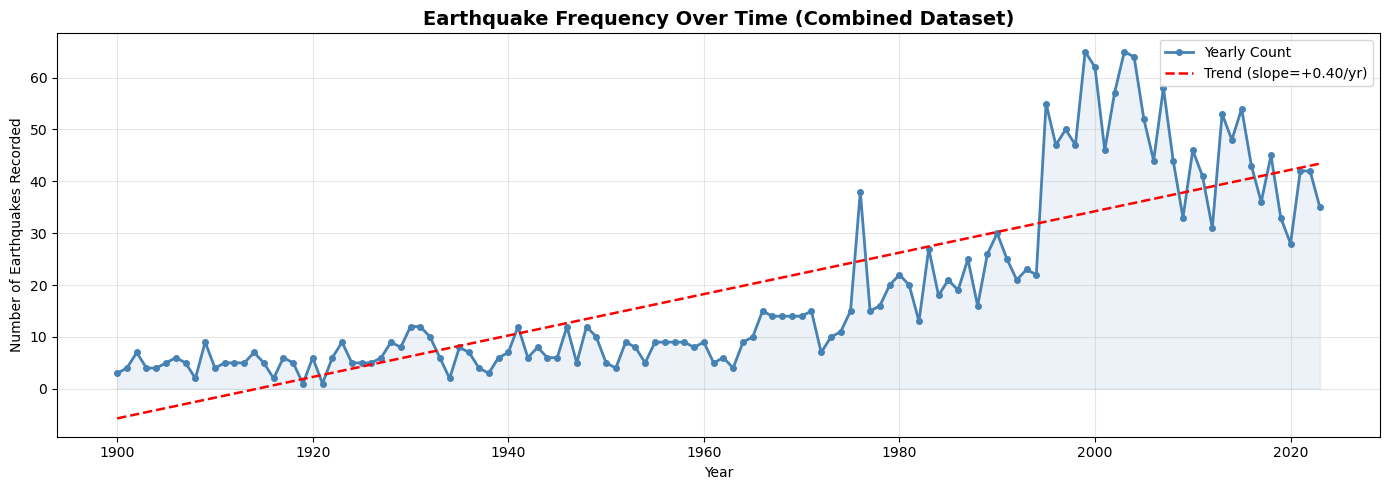

In [175]:
yearly_counts = combined_df.groupby('year').size().reset_index(name='earthquake_count')
z = np.polyfit(yearly_counts['year'], yearly_counts['earthquake_count'], 1)
p_trend = np.poly1d(z)

plt.figure(figsize=(14, 5))
plt.plot(yearly_counts['year'], yearly_counts['earthquake_count'], color='steelblue', linewidth=2, marker='o', markersize=4, label='Yearly Count')
plt.plot(yearly_counts['year'], p_trend(yearly_counts['year']), color='red', linestyle='--', linewidth=1.8, label=f'Trend (slope={z[0]:+.2f}/yr)')
plt.fill_between(yearly_counts['year'], yearly_counts['earthquake_count'], alpha=0.1, color='steelblue')
plt.title('Earthquake Frequency Over Time (Combined Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes Recorded')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Q2) Are there significant differnces among various geographical areas(or nations) for depth of earthquakes and amount of damage caused (SIG)?

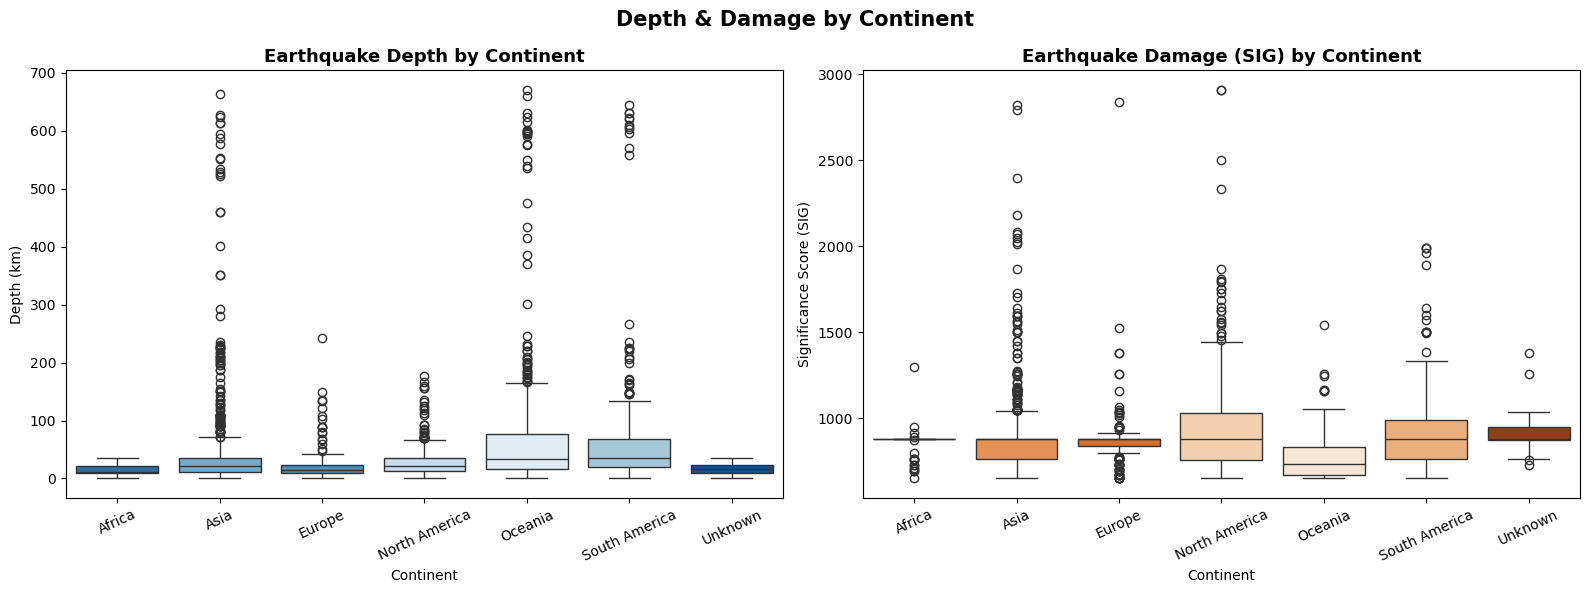

               depth     sig
continent                   
North America  31.04  963.28
Unknown        16.18  928.02
South America  71.76  912.74
Asia           38.50  881.99
Europe         24.26  876.26
Africa         15.26  859.24
Oceania        85.74  773.50


In [176]:
plot_df = combined_df.dropna(subset=['continent', 'depth', 'sig'])
plot_df = plot_df[plot_df['continent'] != 'not identified/island']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=plot_df, x='continent', y='depth', ax=axes[0],
            hue='continent', palette='Blues', legend=False,
            order=sorted(plot_df['continent'].unique()))
axes[0].set_title('Earthquake Depth by Continent', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Continent')
axes[0].set_ylabel('Depth (km)')
axes[0].tick_params(axis='x', rotation=25)

sns.boxplot(data=plot_df, x='continent', y='sig', ax=axes[1],
            hue='continent', palette='Oranges', legend=False,
            order=sorted(plot_df['continent'].unique()))
axes[1].set_title('Earthquake Damage (SIG) by Continent', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Continent')
axes[1].set_ylabel('Significance Score (SIG)')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Depth & Damage by Continent', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(plot_df.groupby('continent')[['depth','sig']].mean().round(2).sort_values('sig', ascending=False))

# Q3) Does the overall relationship between depth of earthquake and extent of damage (SIG) depend on each earthquake's size?

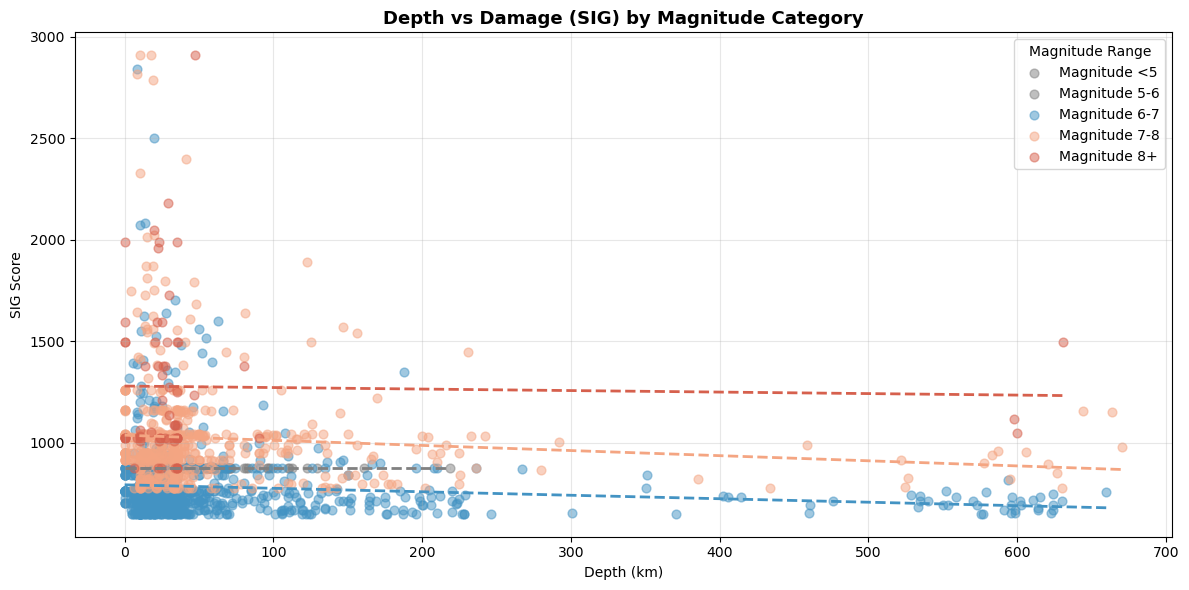

Magnitude <5: r = nan  (n=96)
Magnitude 5-6: r = nan  (n=393)
Magnitude 6-7: r = -0.111  (n=1195)
Magnitude 7-8: r = -0.097  (n=590)
Magnitude 8+: r = -0.024  (n=64)


In [177]:
plot_df3 = combined_df.dropna(subset=['depth', 'sig', 'mag_bin'])
palette = {'6-7': '#4393c3', '7-8': '#f4a582', '8+': '#d6604d'}

plt.figure(figsize=(12, 6))
for cat, grp in plot_df3.groupby('mag_bin', observed=True):
    plt.scatter(grp['depth'], grp['sig'], label=f'Magnitude {cat}', alpha=0.5, s=40, color=palette.get(str(cat), 'gray'))
    if len(grp) > 5:
        z = np.polyfit(grp['depth'], grp['sig'], 1)
        x_line = np.linspace(grp['depth'].min(), grp['depth'].max(), 100)
        plt.plot(x_line, np.poly1d(z)(x_line), linewidth=2, color=palette.get(str(cat), 'gray'), linestyle='--')

plt.title('Depth vs Damage (SIG) by Magnitude Category', fontsize=13, fontweight='bold')
plt.xlabel('Depth (km)')
plt.ylabel('SIG Score')
plt.legend(title='Magnitude Range')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for cat, grp in plot_df3.groupby('mag_bin', observed=True):
    r = grp[['depth','sig']].corr().iloc[0,1]
    print(f"Magnitude {cat}: r = {r:.3f}  (n={len(grp)})")

# Q4 (Re do of question in phase 1 but with new data set) : Is tsunami affected by magnitude?

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\2538235305.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



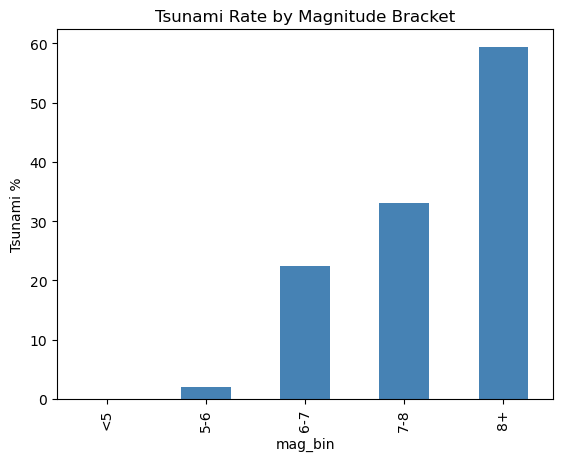

In [178]:
#Magnitudes already split into bins

tsunami_rate = combined_df.groupby('mag_bin')['tsunami'].mean() * 100 #To get how much percent caused tsunamis

tsunami_rate.plot(kind="bar", color="steelblue")
plt.ylabel("Tsunami %")
plt.title("Tsunami Rate by Magnitude Bracket")

plt.show()

# ______________________________________________________________________________________

# Mohamed Hesham 248519's Questions Phase 2

# Q1 Do earthquakes with similar magnitude have different impacts depending on location?

In [179]:
combined_df.groupby(['mag_bin', 'continent'])['sig'].mean() #Showing the mean of the sig of the magnitude bins


C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\1148785587.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



mag_bin  continent            
<5       Africa                    876.918617
         Asia                      876.918617
         Europe                    876.918617
         North America             876.918617
         Oceania                   876.918617
         South America             876.918617
         Unknown                   876.918617
         not identified/island            NaN
5-6      Africa                    876.918617
         Asia                      876.918617
         Europe                    876.918617
         North America             876.918617
         Oceania                   876.918617
         South America             876.918617
         Unknown                   876.918617
         not identified/island            NaN
6-7      Africa                    827.748365
         Asia                      795.604183
         Europe                    835.489236
         North America             836.554703
         Oceania                   707.070673
   

In [180]:
table = combined_df.groupby(['mag_bin', 'continent'])['sig'].mean().unstack() #unstack to make it not a long stacked list 
table

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\1450717387.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



continent,Africa,Asia,Europe,North America,Oceania,South America,Unknown,not identified/island
mag_bin,,,,,,,,
<5,876.918617,876.918617,876.918617,876.918617,876.918617,876.918617,876.918617,NaN
5-6,876.918617,876.918617,876.918617,876.918617,876.918617,876.918617,876.918617,NaN
6-7,827.748365,795.604183,835.489236,836.554703,707.070673,788.227264,830.364124,716.744681
7-8,888.071263,1020.209685,978.012328,1179.765608,897.549146,1038.283864,1044.138928,975.423077
8+,NaN,1269.230020,1104.434113,1568.979654,1030.142857,1415.855816,1379.666667,1071.000000


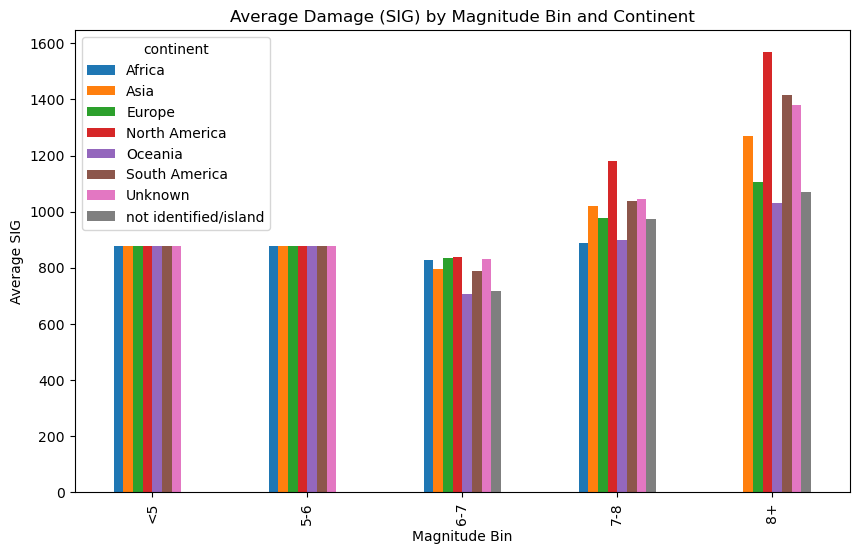

In [181]:
import matplotlib.pyplot as plt

table.plot(kind='bar', figsize=(10,6))

plt.title("Average Damage (SIG) by Magnitude Bin and Continent")
plt.xlabel("Magnitude Bin")
plt.ylabel("Average SIG")

plt.show()


# This table shows that for lower magnitude earthquakes, damage levels are consistent among all regions for the same earthquakes, however, when we get to the bigger magnitude earthquakes, the sig (Damage level) is different between same magnitude but in different regions. This means that there are other factors that contribute to the damage. Not just the intensity of the earthquake. It may be different infrastructure or different elevations.

# Q2 Do earthquakes that occur at night have a higher death rate than the earthquakes that occur during the day?

In [182]:
combined_df['date_time'] = pd.to_datetime(combined_df['date_time']) #Converting to type date time if it wasnt already converted

In [183]:
combined_df['hour'] = combined_df['date_time'].dt.hour #Extracting hour

In [184]:
#Making sure hour extraction worked 
combined_df

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,latitude,longitude,location,continent,country,deaths,mag_bin,depth_category,year,hour
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7.0,4.0,green,0,657.000000,114.0,7.177000,...,-13.8814,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,0.0,6-7,Intermediate,2023,12
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8.0,6.0,yellow,0,775.000000,92.0,0.679000,...,12.8140,-88.1265,"Intipucá, El Salvador",North America,El Salvador,0.0,6-7,Shallow,2023,0
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7.0,5.0,green,0,899.000000,70.0,1.634000,...,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,0.0,6-7,Intermediate,2023,3
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6.0,6.0,green,1,860.000000,173.0,0.907000,...,54.3844,-160.6990,"Sand Point, Alaska",North America,United States of America,0.0,7-8,Shallow,2023,6
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,5.0,5.0,No Warning Issued,1,820.000000,79.0,0.879451,...,54.4900,-160.7960,Alaska Peninsula,North America,United States of America,0.0,7-8,Shallow,2023,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,M 6.9,6.9,2018-08-05 19:46:00,4.0,6.0,no warning issued,0,841.325843,271.5,1.947500,...,-0.7893,113.9213,Indonesia,Asia,Indonesia,0.0,6-7,Shallow,2018,19
2334,M 7.5,7.5,2018-09-28 10:02:00,5.0,7.0,no warning issued,1,1045.642857,271.5,1.947500,...,0.1780,119.8400,Indonesia,Asia,Indonesia,0.0,7-8,Shallow,2018,10
2335,M 7.0,7.0,2020-10-30 11:51:00,4.0,7.0,no warning issued,1,874.328571,70.5,1.970000,...,37.9180,26.7900,"Turkey, Greece",Unknown,"Turkey, Greece",0.0,6-7,Shallow,2020,11
2336,M 6.2,6.2,2022-06-21 21:54:00,4.0,6.0,no warning issued,0,876.918617,70.5,1.970000,...,33.0920,69.5140,"Afghanistan, Pakistan",Unknown,"Afghanistan, Pakistan",1000.0,6-7,Shallow,2022,21


In [185]:
combined_df['time_period'] = combined_df['hour'].apply(
    lambda x: 'Night' if (x >= 19 or x < 4) else 'Day' ) #Lambda function to decide whether its day or night
#We will make it so that night time is from 7pm to 4 am
#The rest will be classified as day

In [186]:
summary = combined_df.groupby('time_period')['deaths'].agg(['mean', 'median', 'count'])
summary

,mean,median,count
time_period,,,
Day,488.055944,0.0,1430
Night,1077.234581,0.0,908


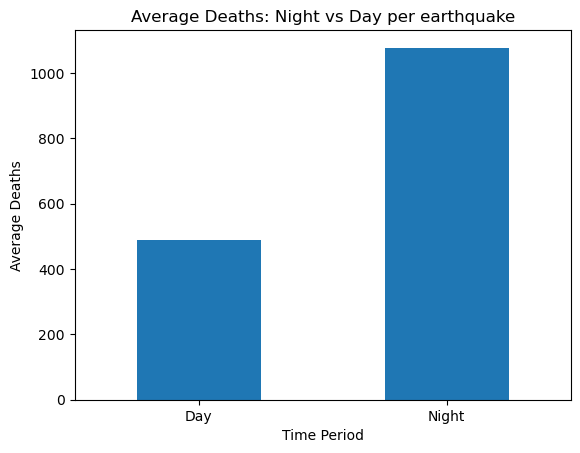

In [187]:
import matplotlib.pyplot as plt

#Plotting average deaths by mean for each time period
combined_df.groupby('time_period')['deaths'].mean().plot(kind='bar')

plt.title("Average Deaths: Night vs Day per earthquake")
plt.ylabel("Average Deaths")
plt.xlabel("Time Period")
plt.xticks(rotation=0)

plt.show()

#This bar chart shows the average number of deaths for each day period

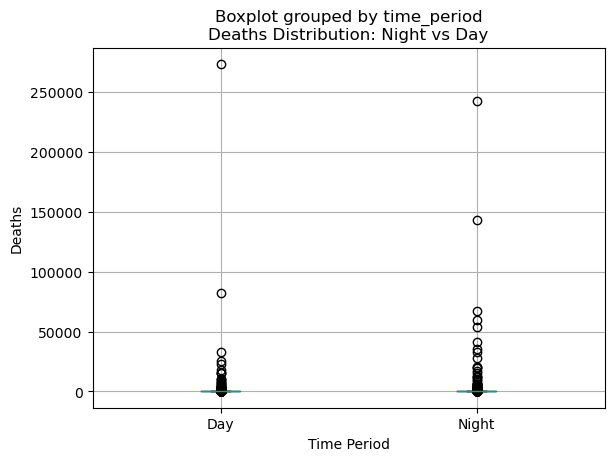

In [188]:
#Show distribution of deaths
combined_df.boxplot(column='deaths', by='time_period')

plt.title("Deaths Distribution: Night vs Day")
plt.xlabel("Time Period")
plt.ylabel("Deaths")

plt.show()

# Answer for question 2: The bar chart shows that earthquakes that occur during the night have a much higher Average death per earthquake. This might be because at night people cant see or people are sleeping. Making them not able to flee into a safe place easily. Or it may have to do with cooling and heating (Earth is cooler during the night). The box plot shows the median at 0 (Most earthquakes dont have reported deaths). It also shows night time earthquakes having more instances of death (More cirlces). There is an odd one out at the very top making day earthquakes have the maximum instance.

# Q3 Is there a threshold magnitude that beyond it, the deaths skyrocket?

In [189]:
mean_deaths = combined_df.groupby('mag_bin')['deaths'].mean()
print(mean_deaths)

#Getting mean for every magnitude bin

mag_bin
<5        3.989583
5-6     110.050891
6-7     191.646025
7-8    1757.945763
8+     5722.046875
Name: deaths, dtype: float64


C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\75546932.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



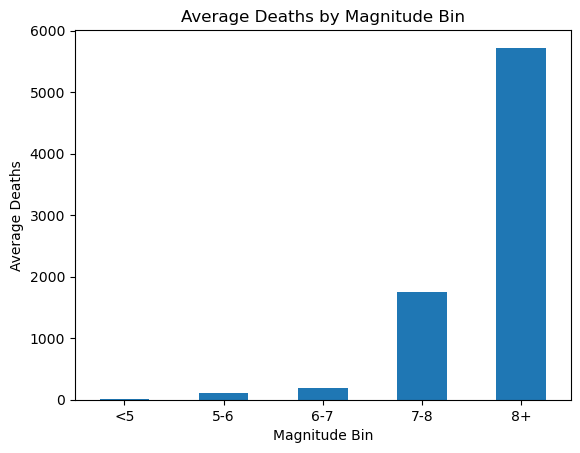

In [190]:
import matplotlib.pyplot as plt

mean_deaths.plot(kind='bar')

plt.title("Average Deaths by Magnitude Bin")
plt.xlabel("Magnitude Bin")
plt.ylabel("Average Deaths")
plt.xticks(rotation=0)

plt.show()

#This bar chart shows the average number of deaths per earthquake magnitude bins

# From less than 5, it is increasing slowly, after that, with the jump to 8, the deaths do skyrocket 

# Q4 Has the average number of deaths per earthquake changed over time?

In [191]:
avg_deaths_per_year = combined_df.groupby('year')['deaths'].mean()
avg_deaths_per_year

#Grouping for average deaths per year to plot the data into a line graph

year
1900      46.666667
1901       1.250000
1902    1780.857143
1903     305.500000
1904     179.250000
           ...     
2019       0.000000
2020       0.000000
2021       0.000000
2022      23.809524
2023    1530.285714
Name: deaths, Length: 124, dtype: float64

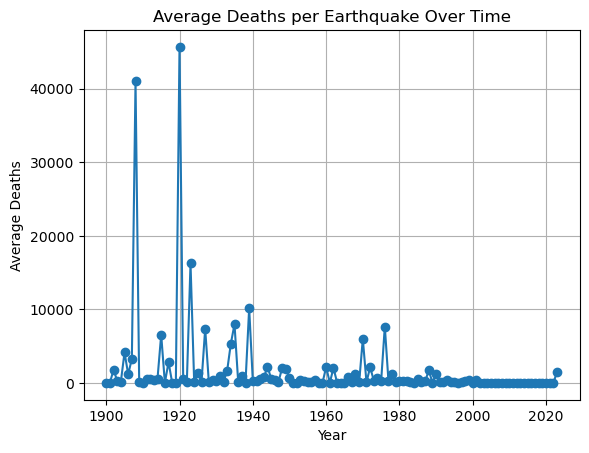

In [192]:
import matplotlib.pyplot as plt

avg_deaths_per_year.plot(kind='line', marker='o')

plt.title("Average Deaths per Earthquake Over Time")
plt.xlabel("Year")
plt.ylabel("Average Deaths")
plt.grid(True)

plt.show()

#This line graph shows the year on the x axis and the average number of deaths from earthquakes on the y axis (Per year)

In [193]:
# It seems to be constant with some outliers. 

# Q5 Are there earthquakes with high magnitude but low deaths and vice versa? 

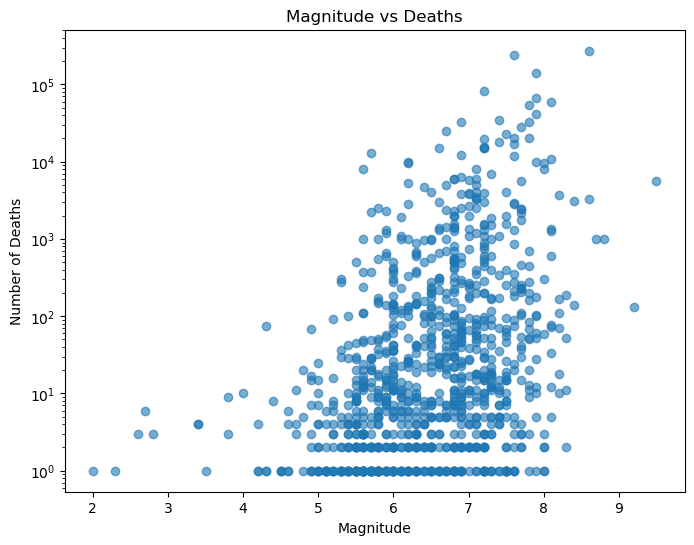

In [194]:
plt.figure(figsize=(8,6))

plt.scatter(combined_df['magnitude'], combined_df['deaths'], alpha=0.6)

plt.xlabel("Magnitude")
plt.ylabel("Number of Deaths")
plt.title("Magnitude vs Deaths")

plt.yscale('log') #So that large numbers dont squash the rest
plt.show()

#This graph plots each earthquake with its magnitude on the x-axis and the number of deaths on its y-axis to see if there is a trend

# Answer to Q5: It does look like there is a trend between the magnitude and the number of deaths an earthquake causes. However, there are instances where an earthquake with a low magnitude causes a lot of deaths and other instances where an earthquake with a high magnitude causes less deaths. 

# Q6 Is the number of deaths different for locations when the magnitude is the same? 

In [195]:
table = combined_df.groupby(['mag_bin','continent'])['deaths'].mean().unstack()
table

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\869836439.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



continent,Africa,Asia,Europe,North America,Oceania,South America,Unknown,not identified/island
mag_bin,,,,,,,,
<5,3.000000,2.191489,6.315789,3.285714,37.000000,3.750000,0.0,NaN
5-6,491.137931,105.885714,12.204082,34.625000,11.500000,41.031250,0.0,NaN
6-7,82.535714,302.246183,546.081081,79.837838,12.395556,83.850000,175.0,0.0
7-8,1233.333333,2844.291829,4756.777778,450.329670,3.811881,1235.292135,13115.4,0.0
8+,NaN,12188.379310,2.600000,32.750000,0.000000,827.666667,189.0,0.0


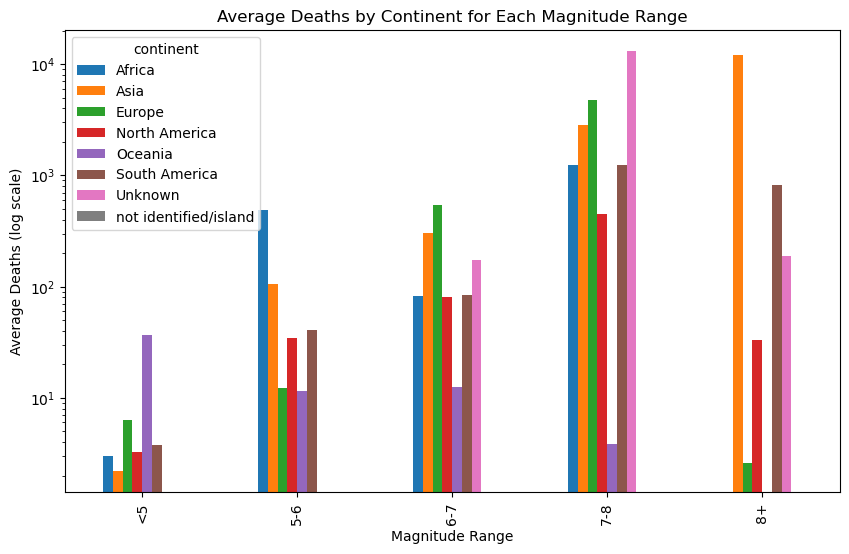

In [196]:
table.plot(kind='bar', figsize=(10,6))

plt.yscale('log')
plt.title("Average Deaths by Continent for Each Magnitude Range")
plt.xlabel("Magnitude Range")
plt.ylabel("Average Deaths (log scale)")

plt.show()

#This bar chart will group mag bins and display the number of average deaths per mag bin for each region

# Deaths in different locations differ for the same magnitude. It may be because of different infrastructure, or the people are trained differently

____________________________________________________________

# Ahmed Gamal's Questions phase two

## 1) Does earthquake depth affect the probability of tsunami occurrence across different regions?
## 2) Does better seismic monitoring (high NST, low GAP) lead to detection of higher or lower magnitude earthquakes?
## 3) How does the distance to the nearest station (dmin) affect data quality indicators such as gap and number of stations (nst)?
## 4) Do earthquakes that occur during night hours differ in magnitude or detection quality compared to daytime earthquakes?
## 5) What is the distribution of alerts?

In [197]:
combined_df.head(2)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,longitude,location,continent,country,deaths,mag_bin,depth_category,year,hour,time_period
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7.0,4.0,green,0,657.0,114.0,7.177,...,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,0.0,6-7,Intermediate,2023,12,Day
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8.0,6.0,yellow,0,775.0,92.0,0.679,...,-88.1265,"Intipucá, El Salvador",North America,El Salvador,0.0,6-7,Shallow,2023,0,Night


# Q1 Does earthquake depth affect the probability of tsunami occurrence across different regions?

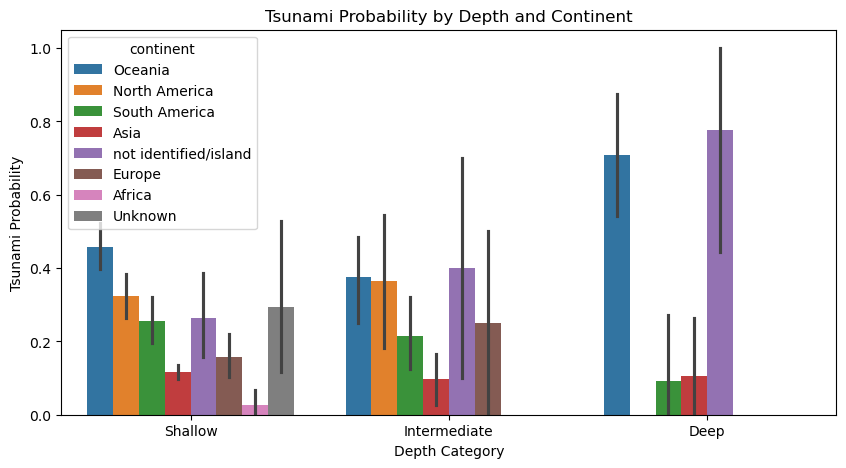

In [198]:
#depth_category already done above 

plt.figure(figsize=(10,5))
sns.barplot(data=combined_df, x="depth_category", y="tsunami", hue="continent")

plt.title("Tsunami Probability by Depth and Continent")
plt.ylabel("Tsunami Probability")
plt.xlabel("Depth Category")
plt.show()

# Q2 Does better seismic monitoring (high NST, low GAP) lead to detection of higher or lower magnitude earthquakes?

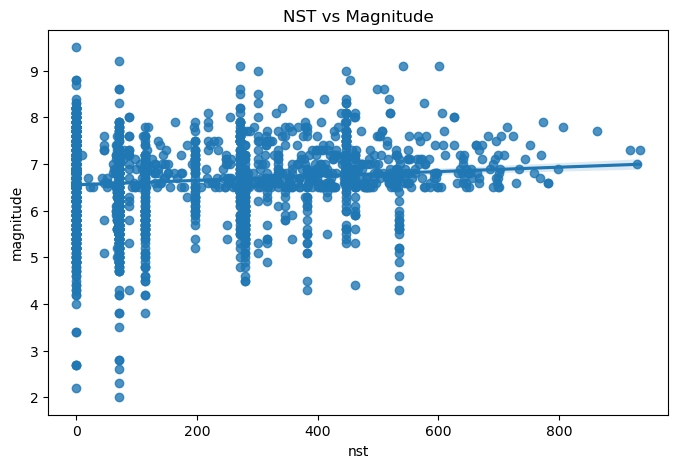

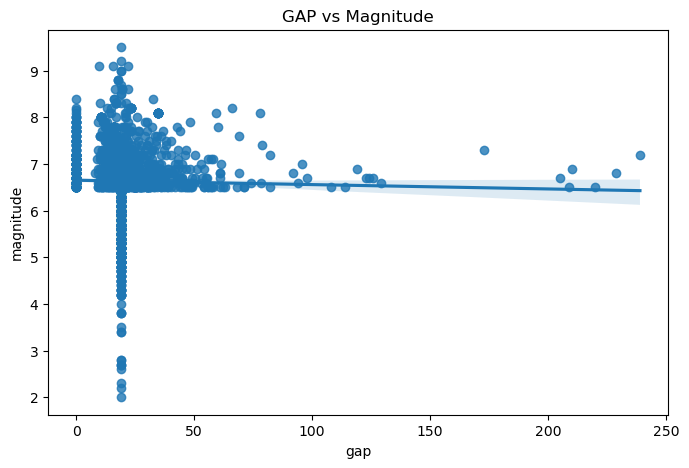

In [199]:
plt.figure(figsize=(8,5))
sns.regplot(data=combined_df, x="nst", y="magnitude")

plt.title("NST vs Magnitude")
plt.show()

plt.figure(figsize=(8,5))
sns.regplot(data=combined_df, x="gap", y="magnitude")

plt.title("GAP vs Magnitude")
plt.show()

# Q3 How does the distance to the nearest station (dmin) affect data quality indicators such as gap and number of stations (nst)?¶

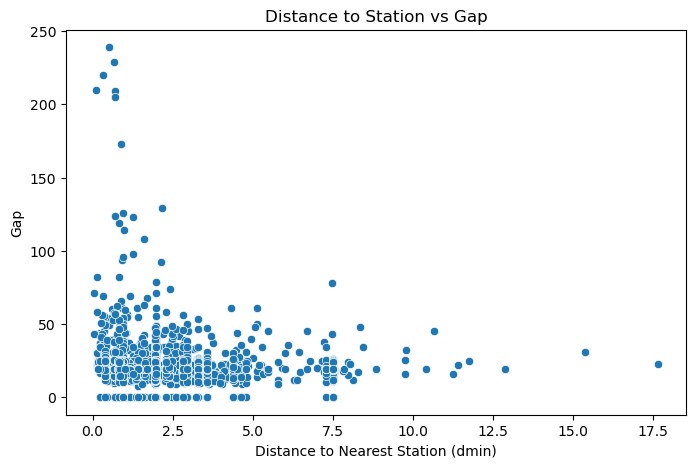

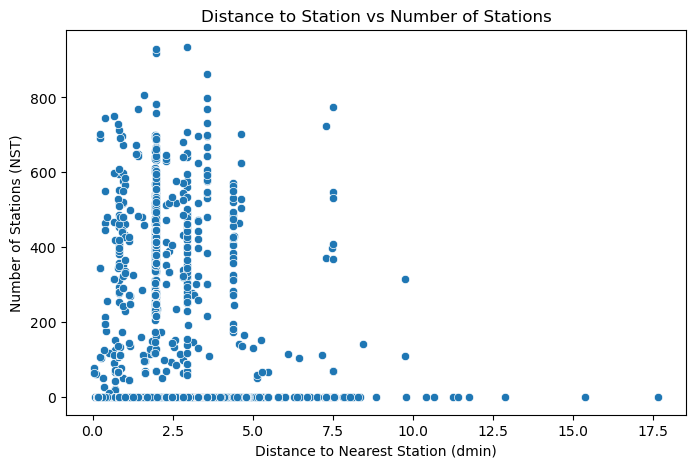

In [200]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=combined_df, x="dmin", y="gap")
plt.title("Distance to Station vs Gap")
plt.xlabel("Distance to Nearest Station (dmin)")
plt.ylabel("Gap")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=combined_df, x="dmin", y="nst")
plt.title("Distance to Station vs Number of Stations")
plt.xlabel("Distance to Nearest Station (dmin)")
plt.ylabel("Number of Stations (NST)")
plt.show()

# Q4 Do earthquakes that occur during night hours differ in magnitude or detection quality compared to daytime earthquakes?

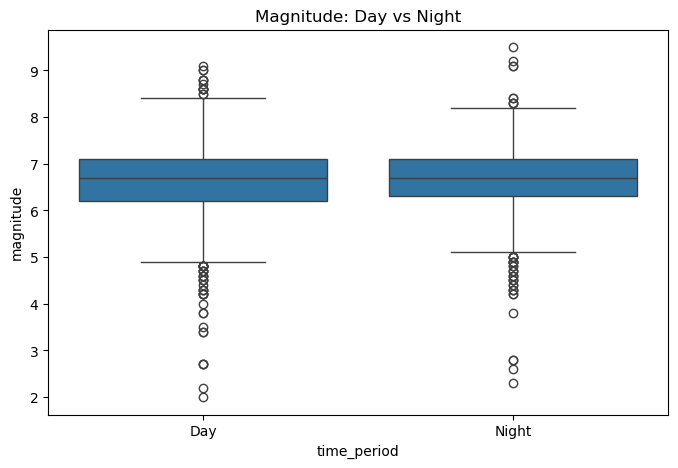

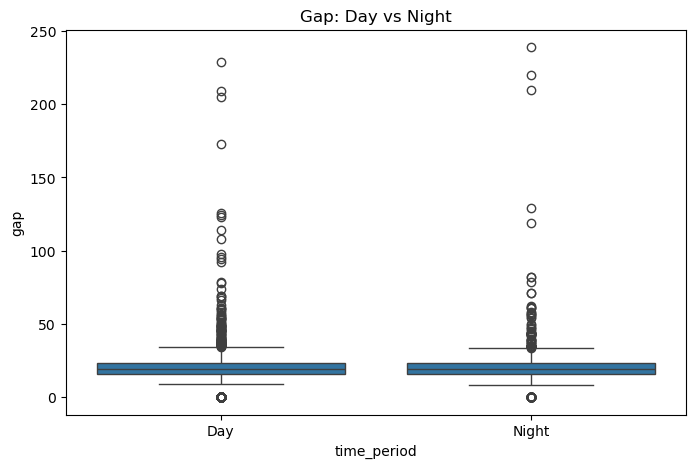

In [201]:
plt.figure(figsize=(8,5))
sns.boxplot(data=combined_df, x="time_period", y="magnitude")
plt.title("Magnitude: Day vs Night")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=combined_df, x="time_period", y="gap")
plt.title("Gap: Day vs Night")
plt.show()

# Question 5: What is the distribution of alerts? 

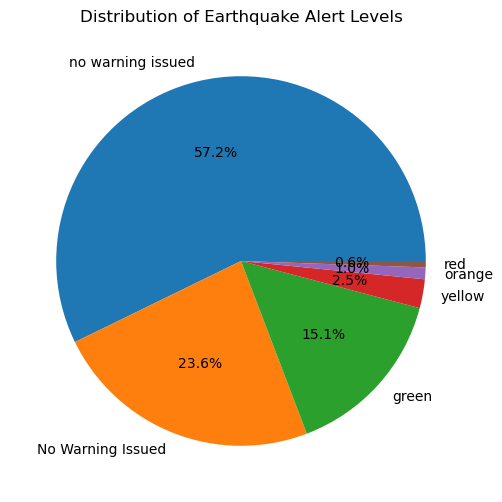

In [202]:
alert_counts = combined_df['alert'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    alert_counts,
    labels=alert_counts.index,
    autopct='%1.1f%%'
)

plt.title("Distribution of Earthquake Alert Levels")

plt.show()

# ________________________________________________________________________________________

# Karim 240829's Questions Phase 2

# Q1 How does magnitude vary across different depth levels?

In [203]:
combined_df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,nst,dmin,...,longitude,location,continent,country,deaths,mag_bin,depth_category,year,hour,time_period
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7.0,4.0,green,0,657.0,114.0,7.177000,...,167.1580,"Sola, Vanuatu",Oceania,Vanuatu,0.0,6-7,Intermediate,2023,12,Day
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8.0,6.0,yellow,0,775.0,92.0,0.679000,...,-88.1265,"Intipucá, El Salvador",North America,El Salvador,0.0,6-7,Shallow,2023,0,Night
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7.0,5.0,green,0,899.0,70.0,1.634000,...,-70.3731,"Loncopué, Argentina",South America,Argentina,0.0,6-7,Intermediate,2023,3,Night
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6.0,6.0,green,1,860.0,173.0,0.907000,...,-160.6990,"Sand Point, Alaska",North America,United States of America,0.0,7-8,Shallow,2023,6,Day
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,5.0,5.0,No Warning Issued,1,820.0,79.0,0.879451,...,-160.7960,Alaska Peninsula,North America,United States of America,0.0,7-8,Shallow,2023,6,Day


In [204]:
result = combined_df.groupby("depth_category")["magnitude"].mean() 
result

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\56283615.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



depth_category
Shallow         6.561698
Intermediate    6.877966
Deep            6.996825
Name: magnitude, dtype: float64

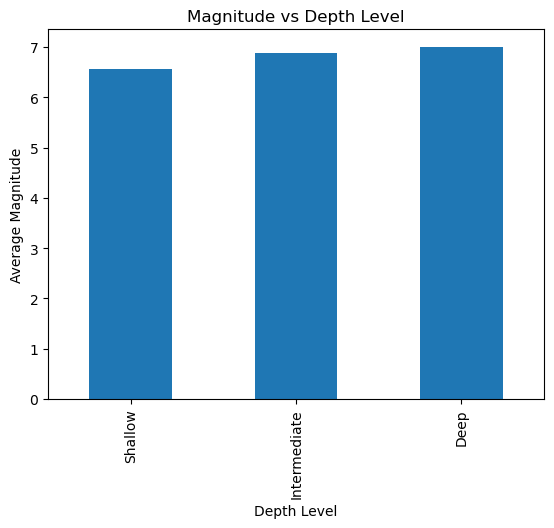

In [205]:
result.plot(kind="bar")
plt.title("Magnitude vs Depth Level")
plt.xlabel("Depth Level")
plt.ylabel("Average Magnitude")
plt.show()

# Q2 Which magnitude range occurs most frequently

In [206]:
counts = combined_df["mag_bin"].value_counts().sort_index()
counts

mag_bin
<5       96
5-6     393
6-7    1195
7-8     590
8+       64
Name: count, dtype: int64

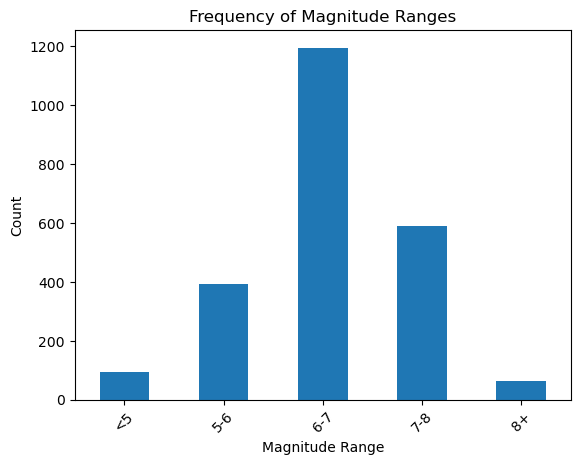

In [207]:
counts.plot(kind="bar")
plt.title("Frequency of Magnitude Ranges")
plt.xlabel("Magnitude Range")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Q3 Do shallow earthquakes produce higher damage?

In [208]:
result = combined_df.groupby("depth_category")["cdi"].mean()
result

C:\Users\mmoha\AppData\Local\Temp\ipykernel_41684\85863906.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



depth_category
Shallow         4.730375
Intermediate    5.080508
Deep            4.174603
Name: cdi, dtype: float64

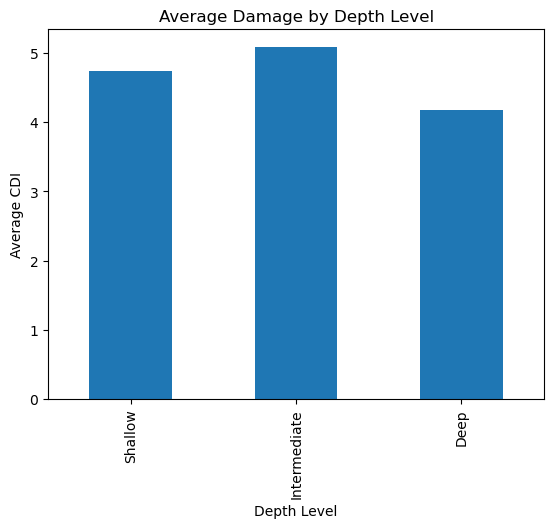

In [209]:
result.plot(kind="bar")
plt.title("Average Damage by Depth Level")
plt.xlabel("Depth Level")
plt.ylabel("Average CDI")
plt.show()